# CCUS patent VAE study with conditional posterior-predictive assessment

This Colab notebook trains the neural models, recomputes the completion, calibration and CPC-prefix results and performs conditional posterior-predictive assessment for the two VAE variants.

Reproducibility safeguards include fixed seeds, deterministic PyTorch settings where supported, stable tie-breaking, model- and text-hashed transformer caches, input/model hashes in the run manifest and a single final results bundle.

Before running, select an **A100 GPU** in Colab and place the input file at:

`/content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv`

Main output folders:

- `figuresForPaper/`: manuscript and appendix figures;
- `tablesForPaper/`: CSV and LaTeX tables plus result macros;
- `simulationForPaper/`: conditional posterior-predictive draws, summaries and manifest;
- `preprocessed/`: split matrices, metadata and validated embedding caches.

The last cell creates and downloads `ccus_revision_results_bundle.zip`.


## 1. Install dependencies and import libraries

Run this cell at the start of a fresh Colab session.


In [ ]:
# Colab already supplies NumPy, pandas, SciPy, scikit-learn, matplotlib and
# a CUDA-enabled PyTorch build. Avoid replacing that core stack because doing
# so can break Colab's CUDA/RAPIDS packages. Install only the missing NLP layer.
%pip -q install --upgrade-strategy only-if-needed "sentence-transformers==6.0.1" "transformers==5.16.1" "accelerate==1.14.0"
!python -m pip check


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 44.5 MB/s eta 0:00:00
ipython 7.34.0 requires jedi, which is not installed.


In [ ]:
import os
# CUBLAS_WORKSPACE_CONFIG must be set before deterministic CUDA matrix operations.
# PYTHONHASHSEED is also recorded, although changing it inside a running Python
# process cannot retroactively alter that process's hash seed.
os.environ.setdefault("PYTHONHASHSEED", "10")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import ast
import json
import math
import random
import pickle
import warnings
import hashlib
import importlib.metadata as importlib_metadata
import platform
import shutil
import sys
import textwrap
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import scipy
import scipy.sparse as sp
from scipy.stats import spearmanr
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


## 2. Configuration, reproducibility settings and Google Drive paths

The manuscript run uses the full settings below. `SIMULATION_DRAWS=1000` provides stable 90% and 95% posterior-predictive intervals while remaining practical on an A100. Reduce it only for a development smoke test.


In [ ]:
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=False)
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")

SEED = 10
FORCE_CPU_FOR_REPRODUCIBILITY = False
REQUIRE_CUDA = True
EXPECTED_GPU_SUBSTRING = 'A100'
CLEAN_PREVIOUS_OUTPUTS = True
FORCE_RECOMPUTE_EMBEDDINGS = False
REUSE_MATCHING_SIMULATION_CACHE = False

def reset_all_seeds(seed: int = SEED) -> None:
    """Reset Python, NumPy and PyTorch random states."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_all_seeds(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as exc:
    print(f"Deterministic PyTorch mode could not be fully enabled: {exc}")

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cpu' if FORCE_CPU_FOR_REPRODUCIBILITY else ('cuda' if torch.cuda.is_available() else 'cpu'))
if REQUIRE_CUDA and DEVICE.type != 'cuda':
    raise RuntimeError("This manuscript run requires a CUDA GPU. In Colab, select an A100 runtime and reconnect.")
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'
print(f"Using device: {DEVICE} ({GPU_NAME})")
if DEVICE.type == 'cuda' and EXPECTED_GPU_SUBSTRING.lower() not in GPU_NAME.lower():
    print(f"WARNING: expected an {EXPECTED_GPU_SUBSTRING} but Colab assigned {GPU_NAME}. The code will run, but runtime may differ.")

PROJECT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/Patents_Adventure/'
INPUT_CSV = os.path.join(PROJECT_FOLDER, 'patents_cleaned_subset_10k.csv')
OUT_DIR = os.path.join(PROJECT_FOLDER, 'preprocessed')
FIG_DIR = os.path.join(PROJECT_FOLDER, 'figuresForPaper')
TABLE_DIR = os.path.join(PROJECT_FOLDER, 'tablesForPaper')
MODEL_DIR = os.path.join(PROJECT_FOLDER, 'modelsForPaper2')
SIM_DIR = os.path.join(PROJECT_FOLDER, 'simulationForPaper')
BUNDLE_PATH = os.path.join(PROJECT_FOLDER, 'ccus_revision_results_bundle.zip')

for directory in [OUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR, SIM_DIR]:
    os.makedirs(directory, exist_ok=True)

if CLEAN_PREVIOUS_OUTPUTS:
    simulation_cleanup_patterns = ['*.csv', '*.json', '*.md', '*.txt']
    if not REUSE_MATCHING_SIMULATION_CACHE:
        simulation_cleanup_patterns.append('*.npz')
    for folder, patterns in [
        (FIG_DIR, ['*.png', '*.pdf']),
        (TABLE_DIR, ['*.csv', '*.tex']),
        (SIM_DIR, simulation_cleanup_patterns),
    ]:
        for pattern in patterns:
            for file_path in Path(folder).glob(pattern):
                file_path.unlink()

# Evaluation settings.
CO2_PREFIXES = ('Y02C', 'B01D53/04', 'B01D53/46', 'B01D53/62')
DOWNSTREAM_PREFIXES = ('B01D53/04', 'B01D53/62')
MASK_RATIO = 0.50
KS = (5, 10, 20)
CURVE_KS = tuple(range(1, 51))
KNN_K = 30

# Training settings.
MAX_EPOCHS = 150
PATIENCE = 12
WARMUP_EPOCHS = 30
BATCH_SIZE = 64
GRAD_CLIP = 50.0

# Conditional posterior-predictive assessment.
RUN_CONDITIONAL_PPC = True
SIMULATION_DRAWS = 1000
SIMULATION_SEED = 20260902
SIMULATION_DOC_BATCH_SIZE = 128
SIMULATION_DRAW_BATCH_SIZE = 8
DOWNLOAD_RESULTS_BUNDLE = True

# Small validation grid for the NB-derived presence VAE. The selected
# architecture is reused for the direct Bernoulli VAE and ProdLDA.
RUN_NBVAE_GRID = True
NBVAE_GRID = [
    {'latent_dim': 20, 'h_enc': (256, 128), 'dropout': 0.20, 'lr': 1e-3},
    {'latent_dim': 20, 'h_enc': (384, 128), 'dropout': 0.35, 'lr': 8e-4},
    {'latent_dim': 50, 'h_enc': (384, 128), 'dropout': 0.35, 'lr': 8e-4},
    {'latent_dim': 50, 'h_enc': (384, 64),  'dropout': 0.35, 'lr': 5e-4},
]
DEFAULT_CONFIG = NBVAE_GRID[0]

# Transformer baselines.
# If left as None, the notebook resolves the current commit once, pins that commit
# for this run and records it in cache metadata and the final manifest.
RUN_PATENTSBERTA = True
PATENTSBERTA_MODEL_NAME = 'AI-Growth-Lab/PatentSBERTa'
PATENTSBERTA_REVISION = None
RUN_PAECTER = True
PAECTER_MODEL_NAME = 'mpi-inno-comp/paecter'
PAECTER_REVISION = None

FIG_LABEL_SIZE = 13
FIG_TICK_SIZE = 12
FIG_LEGEND_SIZE = 11
FIG_TITLE_SIZE = 13
plt.rcParams.update({
    'font.size': FIG_TICK_SIZE,
    'axes.labelsize': FIG_LABEL_SIZE,
    'axes.titlesize': FIG_TITLE_SIZE,
    'xtick.labelsize': FIG_TICK_SIZE,
    'ytick.labelsize': FIG_TICK_SIZE,
    'legend.fontsize': FIG_LEGEND_SIZE,
})

SHORT_MODEL_NAMES = {
    'NB-to-Bernoulli VAE': 'NB-VAE',
    'Direct Bernoulli VAE': 'Bernoulli VAE',
    'ProdLDA': 'ProdLDA',
    'TF-IDF nearest neighbours': 'TF-IDF NN',
    'PatentSBERTa nearest neighbours': 'Patent transformer NN',
    'PaECTER nearest neighbours': 'PaECTER NN',
    'Unigram prior': 'Unigram',
    'NB-VAE latent mean': 'NB-VAE latent',
    'Bernoulli VAE latent mean': 'Bernoulli VAE latent',
    'ProdLDA topic proportions': 'ProdLDA topics',
    'TF-IDF SVD': 'TF-IDF SVD',
    'PaECTER': 'Patent transformer',
}

def short_name(name: str) -> str:
    return SHORT_MODEL_NAMES.get(name, name)

def style_axis(ax, grid_axis: Optional[str] = None) -> None:
    ax.tick_params(axis='both', labelsize=FIG_TICK_SIZE)
    if grid_axis:
        ax.grid(axis=grid_axis, linestyle='--', alpha=0.35)

print("Configured paths:")
print("  INPUT_CSV:", INPUT_CSV)
print("  OUT_DIR:", OUT_DIR)
print("  FIG_DIR:", FIG_DIR)
print("  TABLE_DIR:", TABLE_DIR)
print("  SIM_DIR:", SIM_DIR)


Mounting Google Drive...
Mounted at /content/drive
Using device: cuda (NVIDIA A100-SXM4-40GB)
Configured paths:
  INPUT_CSV: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv
  OUT_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/preprocessed
  FIG_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/figuresForPaper
  TABLE_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/tablesForPaper
  SIM_DIR: /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/simulationForPaper


## 3. Load patents, extract CPC codes and create train/validation/test splits

The vocabulary is fitted only on the training split to avoid preprocessing leakage into validation or test data.

In [ ]:
def normalise_cpc_symbol(symbol: str) -> str:
    if not isinstance(symbol, str):
        return ''
    return symbol.replace(' ', '').strip().upper()


def extract_cpc_from_biblio(biblio_str) -> List[str]:
    try:
        bib = ast.literal_eval(biblio_str)
        cpcs = bib.get('classifications_cpc', {})
        if isinstance(cpcs, dict):
            cpcs = cpcs.get('classifications', [])
        return [normalise_cpc_symbol(c.get('symbol', '')) for c in cpcs if isinstance(c, dict)]
    except Exception:
        return []


def has_prefix(codes: Iterable[str], prefix: str) -> bool:
    prefix = normalise_cpc_symbol(prefix)
    return any(str(code).startswith(prefix) for code in codes)


def any_prefix(codes: Iterable[str], prefixes: Iterable[str]) -> bool:
    return any(has_prefix(codes, p) for p in prefixes)

print(f"Loading {INPUT_CSV}")
if not os.path.isfile(INPUT_CSV):
    raise FileNotFoundError(f"Input CSV not found: {INPUT_CSV}")
df_raw = pd.read_csv(INPUT_CSV)
if 'lang' in df_raw.columns:
    df_raw = df_raw[df_raw['lang'].astype(str).str.lower().eq('en')].copy()

text_col = 'processed_abstract' if 'processed_abstract' in df_raw.columns else 'abstract_text'
if text_col not in df_raw.columns:
    raise ValueError("The dataset must contain either 'processed_abstract' or 'abstract_text'.")
print(f"Using text column: {text_col}")

df_raw['cpc_codes'] = df_raw['biblio'].apply(extract_cpc_from_biblio)
df = df_raw[df_raw['cpc_codes'].apply(lambda codes: any_prefix(codes, CO2_PREFIXES))].copy()
df['raw_text'] = df[text_col].fillna('').astype(str)
for prefix in CO2_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    df[f'has_{safe}'] = df['cpc_codes'].apply(lambda codes, p=prefix: has_prefix(codes, p)).astype(int)

# Labels for the downstream task
for prefix in DOWNSTREAM_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    df[f'label_{safe}'] = df['cpc_codes'].apply(lambda codes, p=prefix: has_prefix(codes, p)).astype(int)

# A composite stratification label helps preserve the two downstream CPC labels.
strat = df[[f'label_{p.replace("/", "_").replace(".", "_")}' for p in DOWNSTREAM_PREFIXES]].astype(str).agg('_'.join, axis=1)
strat_counts = strat.value_counts()
strat_arg = strat if strat_counts.min() >= 3 else None
print('Joint CPC-label stratification:', 'enabled' if strat_arg is not None else 'disabled (a joint stratum has fewer than 3 records)')

idx_all = np.arange(len(df))
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.10, random_state=SEED, shuffle=True, stratify=strat_arg
)
strat_trainval = strat.iloc[idx_trainval] if strat_arg is not None else None
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=1/9, random_state=SEED, shuffle=True, stratify=strat_trainval
)

splits = {
    'train': df.iloc[idx_train].reset_index(drop=True),
    'val': df.iloc[idx_val].reset_index(drop=True),
    'test': df.iloc[idx_test].reset_index(drop=True),
}

vectorizer = CountVectorizer(
    min_df=5,
    max_df=0.95,
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',
    binary=True,
    dtype=np.float32,
)
X_train = vectorizer.fit_transform(splits['train']['raw_text']).tocsr().astype(np.float32)
X_val = vectorizer.transform(splits['val']['raw_text']).tocsr().astype(np.float32)
X_test = vectorizer.transform(splits['test']['raw_text']).tocsr().astype(np.float32)
vocab = np.array(vectorizer.get_feature_names_out())

sp.save_npz(os.path.join(OUT_DIR, 'X_train.npz'), X_train)
sp.save_npz(os.path.join(OUT_DIR, 'X_val.npz'), X_val)
sp.save_npz(os.path.join(OUT_DIR, 'X_test.npz'), X_test)
with open(os.path.join(OUT_DIR, 'vectorizer.pkl'), 'wb') as f:
    pickle.dump(vectorizer, f)
with open(os.path.join(OUT_DIR, 'vocab.json'), 'w') as f:
    json.dump(vocab.tolist(), f)
for name, frame in splits.items():
    frame.to_csv(os.path.join(OUT_DIR, f'metadata_{name}.csv'), index=False)

print("Corpus after filtering:")
print(f"  Documents: {len(df):,}")
print(f"  Train/val/test: {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}")
print(f"  Vocabulary size: {len(vocab):,}")
for prefix in CO2_PREFIXES:
    safe = prefix.replace('/', '_').replace('.', '_')
    print(f"  {prefix}: {df[f'has_{safe}'].sum():,}")


Loading /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/patents_cleaned_subset_10k.csv
Using text column: abstract_text
Joint CPC-label stratification: enabled
Corpus after filtering:
  Documents: 10,603
  Train/val/test: 8,481 / 1,061 / 1,061
  Vocabulary size: 4,412
  Y02C: 10,603
  B01D53/04: 2,742
  B01D53/46: 16
  B01D53/62: 2,789


## 4. Fixed document completion masks

For each validation or test abstract with at least two retained terms, `floor(0.5 × number of terms)` terms are hidden while at least one term remains revealed. The fixed masks ensure that every model and the conditional posterior-predictive assessment use the same observed inputs and held-out positives.


In [ ]:
def make_completion_split(X: sp.csr_matrix, mask_ratio: float = 0.5, seed: int = 0) -> Tuple[sp.csr_matrix, sp.csr_matrix]:
    rng = np.random.default_rng(seed)
    X = X.tocsr()
    obs_rows, obs_cols = [], []
    hold_rows, hold_cols = [], []
    for i in range(X.shape[0]):
        terms = X.getrow(i).indices.copy()
        if terms.size == 0:
            continue
        rng.shuffle(terms)
        if terms.size == 1:
            obs = terms
            held = np.array([], dtype=int)
        else:
            n_hold = max(1, int(np.floor(mask_ratio * terms.size)))
            n_hold = min(n_hold, terms.size - 1)
            held = terms[:n_hold]
            obs = terms[n_hold:]
        obs_rows.extend([i] * len(obs)); obs_cols.extend(obs.tolist())
        hold_rows.extend([i] * len(held)); hold_cols.extend(held.tolist())
    data_obs = np.ones(len(obs_rows), dtype=np.float32)
    data_hold = np.ones(len(hold_rows), dtype=np.float32)
    X_obs = sp.csr_matrix((data_obs, (obs_rows, obs_cols)), shape=X.shape, dtype=np.float32)
    X_hold = sp.csr_matrix((data_hold, (hold_rows, hold_cols)), shape=X.shape, dtype=np.float32)
    return X_obs, X_hold

X_val_obs, X_val_hold = make_completion_split(X_val, MASK_RATIO, seed=SEED + 1)
X_test_obs, X_test_hold = make_completion_split(X_test, MASK_RATIO, seed=SEED + 2)

sp.save_npz(os.path.join(OUT_DIR, 'X_val_observed.npz'), X_val_obs)
sp.save_npz(os.path.join(OUT_DIR, 'X_val_heldout.npz'), X_val_hold)
sp.save_npz(os.path.join(OUT_DIR, 'X_test_observed.npz'), X_test_obs)
sp.save_npz(os.path.join(OUT_DIR, 'X_test_heldout.npz'), X_test_hold)

print("Completion mask sizes:")
print(f"  Validation observed / held-out nnz: {X_val_obs.nnz:,} / {X_val_hold.nnz:,}")
print(f"  Test observed / held-out nnz: {X_test_obs.nnz:,} / {X_test_hold.nnz:,}")

def assert_completion_partition(X_full, X_observed, X_heldout, split_name):
    if X_observed.multiply(X_heldout).nnz != 0:
        raise AssertionError(f"{split_name}: observed and held-out matrices overlap")
    difference = (X_observed + X_heldout - X_full).tocsr()
    difference.eliminate_zeros()
    if difference.nnz != 0:
        raise AssertionError(f"{split_name}: observed plus held-out does not reconstruct the full binary matrix")

assert_completion_partition(X_val, X_val_obs, X_val_hold, 'validation')
assert_completion_partition(X_test, X_test_obs, X_test_hold, 'test')
val_completion_eligible = np.asarray(X_val_hold.sum(axis=1)).ravel() > 0
test_completion_eligible = np.asarray(X_test_hold.sum(axis=1)).ravel() > 0
if np.any(np.asarray(X_val_obs[val_completion_eligible].sum(axis=1)).ravel() < 1):
    raise AssertionError('Every eligible validation document must retain a revealed term')
if np.any(np.asarray(X_test_obs[test_completion_eligible].sum(axis=1)).ravel() < 1):
    raise AssertionError('Every eligible test document must retain a revealed term')
print(f"  Eligible validation/test documents: {val_completion_eligible.sum():,} / {test_completion_eligible.sum():,}")


Completion mask sizes:
  Validation observed / held-out nnz: 17,762 / 17,232
  Test observed / held-out nnz: 17,804 / 17,279
  Eligible validation/test documents: 1,061 / 1,061


## 5. Evaluation helpers

These functions compute document completion, calibration and downstream retrieval metrics. Observed terms are excluded from the completion candidate set.

In [ ]:
def ndcg_from_gains(gains: np.ndarray, k: int) -> float:
    gains = np.asarray(gains, dtype=np.float64)[:k]
    if gains.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, gains.size + 2))
    dcg = np.sum(gains / discounts)
    n_pos = int(np.sum(gains))
    # The ideal list uses all positives in the document, not only positives retrieved in top k.
    return dcg


def evaluate_completion_scores(
    scores: np.ndarray,
    X_obs: sp.csr_matrix,
    X_hold: sp.csr_matrix,
    model_name: str,
    ks: Tuple[int, ...] = KS,
    eps: float = 1e-12,
) -> Dict[str, float]:
    scores = np.asarray(scores, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    max_k = max(ks)
    metric_lists = {f'P@{k}': [] for k in ks}
    metric_lists.update({f'R@{k}': [] for k in ks})
    metric_lists.update({f'nDCG@{k}': [] for k in ks})
    log_prob_sum = 0.0
    held_count = 0

    for i in range(scores.shape[0]):
        obs_idx = X_obs.getrow(i).indices
        held_idx = X_hold.getrow(i).indices
        if held_idx.size == 0:
            continue

        row_scores = np.maximum(scores[i].copy(), eps)
        row_scores[obs_idx] = 0.0
        denom = row_scores.sum()
        if denom <= 0 or not np.isfinite(denom):
            row_scores = np.ones(scores.shape[1], dtype=np.float64)
            row_scores[obs_idx] = 0.0
            denom = row_scores.sum()
        probs = row_scores / max(denom, eps)
        log_prob_sum += np.log(np.maximum(probs[held_idx], eps)).sum()
        held_count += held_idx.size

        rank_scores = scores[i].copy()
        rank_scores[obs_idx] = -np.inf
        order = np.argsort(-rank_scores, kind='mergesort')
        truth = np.zeros(scores.shape[1], dtype=np.int8)
        truth[held_idx] = 1
        gains = truth[order]
        total_pos = held_idx.size
        for k in ks:
            top = gains[:k]
            metric_lists[f'P@{k}'].append(float(top.mean()))
            metric_lists[f'R@{k}'].append(float(top.sum() / total_pos))
            discounts = np.log2(np.arange(2, k + 2))
            dcg = np.sum(top / discounts)
            ideal_len = min(k, total_pos)
            ideal = np.sum(np.ones(ideal_len) / np.log2(np.arange(2, ideal_len + 2)))
            metric_lists[f'nDCG@{k}'].append(float(dcg / ideal if ideal > 0 else 0.0))

    out = {'model': model_name}
    for key, values in metric_lists.items():
        out[key] = float(np.mean(values)) if values else np.nan
    out['PPL'] = float(np.exp(-log_prob_sum / held_count)) if held_count > 0 else np.nan
    return out


def calibration_metrics(
    probs: np.ndarray,
    X_obs: sp.csr_matrix,
    X_hold: sp.csr_matrix,
    model_name: str,
    n_bins: int = 15,
) -> Tuple[Dict[str, float], pd.DataFrame]:
    probs = np.asarray(probs, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    all_p, all_y = [], []
    V = probs.shape[1]
    all_indices = np.arange(V)
    for i in range(probs.shape[0]):
        if X_hold.getrow(i).nnz == 0:
            continue
        obs_idx = X_obs.getrow(i).indices
        mask = np.ones(V, dtype=bool)
        mask[obs_idx] = False
        y = np.zeros(V, dtype=np.float32)
        y[X_hold.getrow(i).indices] = 1.0
        all_p.append(probs[i, mask])
        all_y.append(y[mask])
    p = np.concatenate(all_p) if all_p else np.array([])
    y = np.concatenate(all_y) if all_y else np.array([])
    if p.size == 0:
        return {'model': model_name, 'ECE': np.nan, 'Brier': np.nan}, pd.DataFrame()

    p = np.clip(p, 0.0, 1.0)
    brier = float(np.mean((p - y) ** 2))
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    ece = 0.0
    for b in range(n_bins):
        lo, hi = bins[b], bins[b + 1]
        if b < n_bins - 1:
            m = (p >= lo) & (p < hi)
        else:
            m = (p >= lo) & (p <= hi)
        if m.sum() == 0:
            rows.append({'model': model_name, 'bin': b, 'mid': (lo + hi) / 2, 'conf': np.nan, 'freq': np.nan, 'mass': 0.0})
            continue
        conf = float(p[m].mean())
        freq = float(y[m].mean())
        mass = float(m.mean())
        ece += mass * abs(freq - conf)
        rows.append({'model': model_name, 'bin': b, 'mid': (lo + hi) / 2, 'conf': conf, 'freq': freq, 'mass': mass})
    return {'model': model_name, 'ECE': float(ece), 'Brier': brier}, pd.DataFrame(rows)


def precision_at_n(y_true: np.ndarray, y_score: np.ndarray, n: int = 100) -> float:
    n = min(n, len(y_true))
    order = np.argsort(-y_score, kind='mergesort')[:n]
    return float(np.mean(y_true[order]))


## 6. Neural model definitions

The NB-derived presence VAE and direct Bernoulli VAE share the same encoder and mirrored MLP capacity. The former derives a Bernoulli presence probability from the negative binomial zero probability, it does not fit observed word counts. ProdLDA reuses the selected encoder dimensions and training protocol but is a separate topic model baseline, not a decoder only ablation.


In [ ]:
class MLPEncoder(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        layers = []
        in_dim = vocab_size
        for h in h_enc:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.body = nn.Sequential(*layers)
        self.mu = nn.Linear(in_dim, latent_dim)
        self.logvar = nn.Linear(in_dim, latent_dim)

    def forward(self, x):
        h = self.body(x)
        return self.mu(h), self.logvar(h)


def reparam(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


def gaussian_kl(mu, logvar):
    return 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1.0, dim=1)


class NBPresenceVAE(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35, a_max=10.0):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        h_dec = tuple(reversed(h_enc))
        layers = []
        in_dim = latent_dim
        for h in h_dec:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.decoder = nn.Sequential(*layers)
        self.alpha_head = nn.Linear(in_dim, vocab_size)
        self.rho_head = nn.Linear(in_dim, vocab_size)
        self.a_max = a_max

    def decode_pi(self, z):
        h = self.decoder(z)
        alpha = torch.exp(torch.clamp(self.alpha_head(h), -self.a_max, self.a_max)) + 1e-6
        log_rho = F.logsigmoid(-self.rho_head(h))
        # log_zero = log P(m=0). Clamping away from zero prevents an exact
        # presence probability of zero while retaining the documented link.
        log_zero = (alpha * log_rho).clamp(max=-1e-7)
        pi = (-torch.expm1(log_zero)).clamp(min=1e-7, max=1.0 - 1e-7)
        return pi, log_zero

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        pi, log_zero = self.decode_pi(z)
        # log(-expm1(log_zero)) is the stable log(1-exp(log_zero)) form.
        log_pi = torch.log(-torch.expm1(log_zero))
        log_prob = torch.where(x.bool(), log_pi, log_zero)
        recon = -log_prob.sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        pi, _ = self.decode_pi(z)
        return pi

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return mu


class BernoulliVAE(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        h_dec = tuple(reversed(h_enc))
        layers = []
        in_dim = latent_dim
        for h in h_dec:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.decoder = nn.Sequential(*layers)
        self.logit_head = nn.Linear(in_dim, vocab_size)

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        logits = self.logit_head(self.decoder(z))
        recon = F.binary_cross_entropy_with_logits(logits, x, reduction='none').sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        logits = self.logit_head(self.decoder(z))
        return torch.sigmoid(logits).clamp(min=1e-7, max=1.0 - 1e-7)

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return mu


class ProdLDA(nn.Module):
    def __init__(self, vocab_size: int, latent_dim: int, h_enc=(384, 128), dropout=0.35):
        super().__init__()
        self.encoder = MLPEncoder(vocab_size, latent_dim, h_enc, dropout)
        self.topic_word = nn.Parameter(torch.randn(latent_dim, vocab_size) * 0.02)

    def loss(self, x, beta=1.0):
        mu, logvar = self.encoder(x)
        z = reparam(mu, logvar)
        theta = torch.softmax(z, dim=1)
        logits = theta @ self.topic_word
        log_word = torch.log_softmax(logits, dim=1)
        recon = -(x * log_word).sum(dim=1).mean()
        kl = gaussian_kl(mu, logvar).mean()
        return recon + beta * kl, recon.detach(), kl.detach()

    @torch.no_grad()
    def predict(self, x, deterministic=True):
        mu, logvar = self.encoder(x)
        z = mu if deterministic else reparam(mu, logvar)
        theta = torch.softmax(z, dim=1)
        logits = theta @ self.topic_word
        return torch.softmax(logits, dim=1).clamp(min=1e-12)

    @torch.no_grad()
    def encode_mu(self, x):
        mu, _ = self.encoder(x)
        return torch.softmax(mu, dim=1)


## 7. Training and prediction utilities

The neural models train on complete binary training vectors. Validation/test completion and calibration pass the fixed masked vectors to the encoder and decode deterministically at the encoder posterior mean. The later conditional posterior-predictive assessment is distinct: it repeatedly samples the latent posterior and the Bernoulli observation model.


In [ ]:

def csr_to_dense_float(X: sp.csr_matrix) -> np.ndarray:
    return X.toarray().astype(np.float32)

X_train_dense = csr_to_dense_float(X_train)
X_val_obs_dense = csr_to_dense_float(X_val_obs)
X_test_obs_dense = csr_to_dense_float(X_test_obs)
X_val_dense = csr_to_dense_float(X_val)
X_test_dense = csr_to_dense_float(X_test)


def predict_in_batches(model: nn.Module, X_dense: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, X_dense.shape[0], batch_size):
            xb = torch.from_numpy(X_dense[start:start+batch_size]).to(DEVICE)
            out = model.predict(xb).detach().cpu().numpy()
            outputs.append(out)
    return np.vstack(outputs).astype(np.float32)


def encode_in_batches(model: nn.Module, X_dense: np.ndarray, batch_size: int = 256) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, X_dense.shape[0], batch_size):
            xb = torch.from_numpy(X_dense[start:start+batch_size]).to(DEVICE)
            out = model.encode_mu(xb).detach().cpu().numpy()
            outputs.append(out)
    return np.vstack(outputs).astype(np.float32)


def train_neural_model(
    model: nn.Module,
    model_name: str,
    train_dense: np.ndarray,
    val_obs_dense: np.ndarray,
    X_val_obs: sp.csr_matrix,
    X_val_hold: sp.csr_matrix,
    lr: float,
    max_epochs: int = MAX_EPOCHS,
    patience: int = PATIENCE,
    batch_size: int = BATCH_SIZE,
    warmup_epochs: int = WARMUP_EPOCHS,
    save_path: Optional[str] = None,
    seed: int = SEED,
) -> Tuple[nn.Module, pd.DataFrame, Dict[str, float]]:
    reset_all_seeds(seed)
    model = model.to(DEVICE)
    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)
    loader = DataLoader(
        TensorDataset(torch.from_numpy(train_dense)),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        generator=loader_generator,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    best_val_ppl = math.inf
    best_epoch = 0
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        beta = min(1.0, epoch / warmup_epochs)
        losses, recons, kls = [], [], []
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            loss, recon, kl = model.loss(xb, beta=beta)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())

        val_scores = predict_in_batches(model, val_obs_dense)
        val_metrics = evaluate_completion_scores(val_scores, X_val_obs, X_val_hold, model_name=model_name)
        val_ppl = val_metrics['PPL']
        history.append({
            'epoch': epoch, 'beta': beta, 'train_loss': float(np.mean(losses)),
            'train_recon': float(np.mean(recons)), 'train_kl': float(np.mean(kls)),
            'val_ppl': float(val_ppl), 'val_P@5': val_metrics.get('P@5', np.nan),
            'val_nDCG@5': val_metrics.get('nDCG@5', np.nan),
        })
        print(f"{model_name} | epoch {epoch:03d} | loss {np.mean(losses):.2f} | val PPL {val_ppl:.2f}")
        if np.isfinite(val_ppl) and val_ppl < best_val_ppl:
            best_val_ppl = float(val_ppl)
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            if save_path:
                torch.save(best_state, save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping {model_name} at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    summary = {'model': model_name, 'best_epoch': best_epoch, 'best_val_ppl': best_val_ppl}
    return model, history_df, summary


def build_model(model_kind: str, config: Dict) -> nn.Module:
    kwargs = dict(vocab_size=len(vocab), latent_dim=config['latent_dim'], h_enc=tuple(config['h_enc']), dropout=config['dropout'])
    if model_kind == 'nbvae':
        return NBPresenceVAE(**kwargs)
    if model_kind == 'bernvae':
        return BernoulliVAE(**kwargs)
    if model_kind == 'prodlda':
        return ProdLDA(**kwargs)
    raise ValueError(model_kind)


## 8. Select NB-VAE hyperparameters and train neural models

The NB-derived VAE grid selects architecture and learning rate on validation completion perplexity. The chosen capacity and training settings are then reused for the direct Bernoulli VAE and ProdLDA. These are matched single seed fits, not replicated or seed paired causal comparisons between model families.


Running NB-VAE validation grid

Grid config 0 {'latent_dim': 20, 'h_enc': (256, 128), 'dropout': 0.2, 'lr': 0.001}
NB-VAE-grid-0 | epoch 001 | loss 358.87 | val PPL 1998.08
NB-VAE-grid-0 | epoch 002 | loss 154.76 | val PPL 1275.85
NB-VAE-grid-0 | epoch 003 | loss 152.06 | val PPL 1210.61
NB-VAE-grid-0 | epoch 004 | loss 151.49 | val PPL 1210.16
NB-VAE-grid-0 | epoch 005 | loss 151.04 | val PPL 1211.54
NB-VAE-grid-0 | epoch 006 | loss 149.90 | val PPL 1143.55
NB-VAE-grid-0 | epoch 007 | loss 145.53 | val PPL 946.14
NB-VAE-grid-0 | epoch 008 | loss 141.92 | val PPL 878.09
NB-VAE-grid-0 | epoch 009 | loss 139.90 | val PPL 825.41
NB-VAE-grid-0 | epoch 010 | loss 138.24 | val PPL 793.38
NB-VAE-grid-0 | epoch 011 | loss 136.84 | val PPL 767.03
NB-VAE-grid-0 | epoch 012 | loss 135.44 | val PPL 748.57
NB-VAE-grid-0 | epoch 013 | loss 134.24 | val PPL 736.61
NB-VAE-grid-0 | epoch 014 | loss 133.17 | val PPL 710.32
NB-VAE-grid-0 | epoch 015 | loss 132.20 | val PPL 691.65
NB-VAE-grid-0 | epoch 01

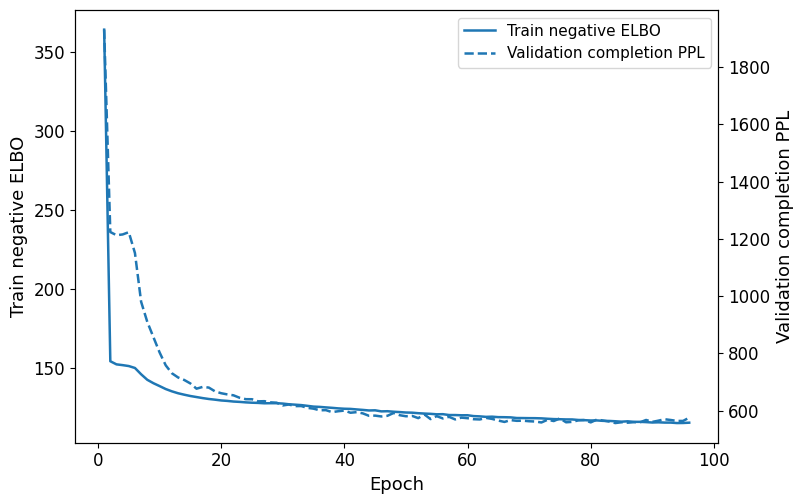

In [ ]:

selection_rows = []
if RUN_NBVAE_GRID:
    print("Running NB-VAE validation grid")
    for cfg_id, cfg in enumerate(NBVAE_GRID):
        run_seed = SEED + 100 + cfg_id
        reset_all_seeds(run_seed)
        print("\nGrid config", cfg_id, cfg)
        model = build_model('nbvae', cfg)
        _, hist, summ = train_neural_model(
            model, f'NB-VAE-grid-{cfg_id}', X_train_dense, X_val_obs_dense, X_val_obs, X_val_hold,
            lr=cfg['lr'], max_epochs=min(80, MAX_EPOCHS), patience=8,
            save_path=os.path.join(MODEL_DIR, f'nbvae_grid_{cfg_id}.pt'),
            seed=run_seed,
        )
        row = {'cfg_id': cfg_id, **cfg, **summ}
        selection_rows.append(row)
    selection_df = pd.DataFrame(selection_rows)
    selection_df.to_csv(os.path.join(TABLE_DIR, 'nbvae_grid_selection.csv'), index=False)
    best_row = selection_df.sort_values('best_val_ppl').iloc[0]
    h_enc = best_row['h_enc'] if isinstance(best_row['h_enc'], (list, tuple)) else DEFAULT_CONFIG['h_enc']
    selected_config = {
        'latent_dim': int(best_row['latent_dim']),
        'h_enc': tuple(h_enc),
        'dropout': float(best_row['dropout']),
        'lr': float(best_row['lr']),
    }
else:
    selection_df = pd.DataFrame()
    selected_config = DEFAULT_CONFIG.copy()

print("Selected neural configuration:", selected_config)

neural_models = {}
neural_histories = {}
neural_summaries = []

for model_idx, (kind, display) in enumerate([('nbvae', 'NB-to-Bernoulli VAE'), ('bernvae', 'Direct Bernoulli VAE'), ('prodlda', 'ProdLDA')]):
    run_seed = SEED + 1000 + model_idx
    reset_all_seeds(run_seed)
    print("\nTraining final", display)
    model = build_model(kind, selected_config)
    model_path = os.path.join(MODEL_DIR, f'{kind}_best.pt')
    model, hist, summ = train_neural_model(
        model, display, X_train_dense, X_val_obs_dense, X_val_obs, X_val_hold,
        lr=selected_config['lr'], max_epochs=MAX_EPOCHS, patience=PATIENCE,
        save_path=model_path,
        seed=run_seed,
    )
    neural_models[display] = model
    neural_histories[display] = hist
    neural_summaries.append(summ)

pd.DataFrame(neural_summaries).to_csv(os.path.join(TABLE_DIR, 'neural_model_selection.csv'), index=False)

# Figure 1: training curve for the selected NB-VAE.
hist_nb = neural_histories['NB-to-Bernoulli VAE']
fig, ax1 = plt.subplots(figsize=(8.2, 5.2))
ax1.plot(hist_nb['epoch'], hist_nb['train_loss'], label='Train negative ELBO', linewidth=1.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train negative ELBO')
style_axis(ax1)
ax2 = ax1.twinx()
ax2.plot(hist_nb['epoch'], hist_nb['val_ppl'], linestyle='--', label='Validation completion PPL', linewidth=1.8)
ax2.set_ylabel('Validation completion PPL')
style_axis(ax2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=FIG_LEGEND_SIZE)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'training_curves_nbvae.png'), dpi=300, bbox_inches='tight')
plt.show()


## 9. Document-completion and calibration evaluation for neural models

This cell evaluates the three neural models on the held-out test set using the fixed completion mask.

In [ ]:

completion_rows = []
calibration_rows = []
calibration_bins_all = []
test_score_cache = {}

for display, model in neural_models.items():
    print("Predicting test scores for", display)
    scores = predict_in_batches(model, X_test_obs_dense)
    test_score_cache[display] = scores
    completion_rows.append(evaluate_completion_scores(scores, X_test_obs, X_test_hold, display))
    # ProdLDA outputs a categorical word distribution, so calibration as term presence is not reported.
    if display != 'ProdLDA':
        c_metrics, c_bins = calibration_metrics(scores, X_test_obs, X_test_hold, display)
        calibration_rows.append(c_metrics)
        calibration_bins_all.append(c_bins)

completion_df = pd.DataFrame(completion_rows)
calibration_df = pd.DataFrame(calibration_rows)
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_neural.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_neural.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_neural.csv'), index=False)
print(completion_df)
print(calibration_df)


Predicting test scores for NB-to-Bernoulli VAE
Predicting test scores for Direct Bernoulli VAE
Predicting test scores for ProdLDA
                  model       P@5      P@10      P@20       R@5      R@10  \
0   NB-to-Bernoulli VAE  0.350801  0.271725  0.199340  0.114620  0.176285   
1  Direct Bernoulli VAE  0.356645  0.271913  0.201932  0.119330  0.179003   
2               ProdLDA  0.253346  0.190858  0.142696  0.083496  0.125591   

       R@20    nDCG@5   nDCG@10   nDCG@20         PPL  
0  0.256622  0.383794  0.321646  0.298323  578.908311  
1  0.261988  0.390537  0.325297  0.304496  573.734788  
2  0.186674  0.285651  0.233480  0.218408  987.576775  
                  model       ECE     Brier
0   NB-to-Bernoulli VAE  0.001549  0.003397
1  Direct Bernoulli VAE  0.002167  0.003430


## 10. Unigram and TF-IDF nearest neighbour baselines

The unigram prior is a document-independent training presence rate. The TF-IDF baseline uses 30 cosine nearest neighbours from the training split and predicts each term by their normalized non-negative cosine similarity-weighted binary term presence average.


In [ ]:

def repeat_row(row: np.ndarray, n: int) -> np.ndarray:
    return np.broadcast_to(row.reshape(1, -1), (n, row.size)).copy()


def knn_term_scores_from_sparse(train_repr, query_repr, X_train_binary: sp.csr_matrix, k: int = 30, batch_size: int = 128) -> np.ndarray:
    nn = NearestNeighbors(n_neighbors=min(k, X_train_binary.shape[0]), metric='cosine')
    nn.fit(train_repr)
    all_scores = []
    for start in tqdm(range(0, query_repr.shape[0], batch_size), desc='KNN term scores'):
        q = query_repr[start:start+batch_size]
        dist, idx = nn.kneighbors(q, return_distance=True)
        sim = np.maximum(1.0 - dist, 0.0) + 1e-6
        for weights, neigh in zip(sim, idx):
            weights = weights / weights.sum()
            neigh_matrix = X_train_binary[neigh].astype(np.float32)
            score = np.asarray(weights @ neigh_matrix).ravel()
            all_scores.append(score.astype(np.float32))
    return np.vstack(all_scores)

# Unigram raw presence rates from training documents
unigram_raw = np.asarray(X_train.mean(axis=0)).ravel().astype(np.float32)
unigram_scores = repeat_row(np.clip(unigram_raw, 1e-7, 1.0 - 1e-7), X_test.shape[0])
completion_rows.append(evaluate_completion_scores(unigram_scores, X_test_obs, X_test_hold, 'Unigram prior'))
c_metrics, c_bins = calibration_metrics(unigram_scores, X_test_obs, X_test_hold, 'Unigram prior')
calibration_rows.append(c_metrics)
calibration_bins_all.append(c_bins)
test_score_cache['Unigram prior'] = unigram_scores

# TF-IDF nearest-neighbour completion
print("Computing TF-IDF nearest-neighbour baseline")
tfidf_transformer = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
X_train_tfidf = tfidf_transformer.fit_transform(X_train)
X_test_obs_tfidf = tfidf_transformer.transform(X_test_obs)
tfidf_scores = knn_term_scores_from_sparse(X_train_tfidf, X_test_obs_tfidf, X_train, k=KNN_K)
completion_rows.append(evaluate_completion_scores(tfidf_scores, X_test_obs, X_test_hold, 'TF-IDF nearest neighbours'))
c_metrics, c_bins = calibration_metrics(tfidf_scores, X_test_obs, X_test_hold, 'TF-IDF nearest neighbours')
calibration_rows.append(c_metrics)
calibration_bins_all.append(c_bins)
test_score_cache['TF-IDF nearest neighbours'] = tfidf_scores

completion_df = pd.DataFrame(completion_rows)
calibration_df = pd.DataFrame(calibration_rows)
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_with_simple_baselines.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_with_simple_baselines.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_with_simple_baselines.csv'), index=False)
print(completion_df)
print(calibration_df)


Computing TF-IDF nearest-neighbour baseline


KNN term scores:   0%|          | 0/9 [00:00<?, ?it/s]

                       model       P@5      P@10      P@20       R@5  \
0        NB-to-Bernoulli VAE  0.350801  0.271725  0.199340  0.114620   
1       Direct Bernoulli VAE  0.356645  0.271913  0.201932  0.119330   
2                    ProdLDA  0.253346  0.190858  0.142696  0.083496   
3              Unigram prior  0.243921  0.184166  0.135627  0.079533   
4  TF-IDF nearest neighbours  0.550801  0.477945  0.381668  0.186111   

       R@10      R@20    nDCG@5   nDCG@10   nDCG@20          PPL  
0  0.176285  0.256622  0.383794  0.321646  0.298323   578.908311  
1  0.179003  0.261988  0.390537  0.325297  0.304496   573.734788  
2  0.125591  0.186674  0.285651  0.233480  0.218408   987.576775  
3  0.120978  0.176454  0.278008  0.227098  0.209973  1101.840586  
4  0.317135  0.490095  0.583859  0.529687  0.525084  2695.355591  
                       model       ECE     Brier
0        NB-to-Bernoulli VAE  0.001549  0.003397
1       Direct Bernoulli VAE  0.002167  0.003430
2              Uni

## 11. Patent-transformer nearest-neighbour baselines

PatentSBERTa and PaECTER are evaluated separately. Training embeddings use complete training text. Each test completion query is a pseudo-abstract formed only from revealed vocabulary terms, so held-out terms cannot enter the transformer input. Cache reuse requires an exact match on model commit and input text hash.


In [ ]:
def observed_terms_to_texts(X_obs: sp.csr_matrix, vocab: np.ndarray, max_terms: Optional[int] = None) -> List[str]:
    texts = []
    X_obs = X_obs.tocsr()
    for row_index in range(X_obs.shape[0]):
        indices = X_obs.getrow(row_index).indices
        if max_terms is not None and indices.size > max_terms:
            indices = indices[:max_terms]
        text = ' '.join(vocab[indices].tolist())
        texts.append(text if text.strip() else 'empty')
    return texts


def fingerprint_texts(texts: List[str]) -> str:
    digest = hashlib.sha256()
    for item in texts:
        encoded = str(item).encode('utf-8')
        digest.update(len(encoded).to_bytes(8, byteorder='little', signed=False))
        digest.update(encoded)
    return digest.hexdigest()


RESOLVED_MODEL_REVISIONS: Dict[str, str] = {}
_SENTENCE_MODEL_CACHE: Dict[Tuple[str, str], object] = {}


def resolve_model_revision(model_name: str, requested_revision: Optional[str]) -> str:
    cache_key = f"{model_name}@{requested_revision or 'default'}"
    if cache_key in RESOLVED_MODEL_REVISIONS:
        return RESOLVED_MODEL_REVISIONS[cache_key]
    try:
        from huggingface_hub import HfApi
        info = HfApi().model_info(model_name, revision=requested_revision)
        resolved = str(info.sha or requested_revision or 'unresolved')
    except Exception as exc:
        if requested_revision is None:
            raise RuntimeError(f"Could not resolve a reproducible revision for {model_name}: {exc}") from exc
        resolved = str(requested_revision)
    RESOLVED_MODEL_REVISIONS[cache_key] = resolved
    return resolved


def encode_sentence_transformer(
    model_name: str,
    texts: List[str],
    cache_name: str,
    batch_size: int = 32,
    requested_revision: Optional[str] = None,
) -> np.ndarray:
    cache_path = Path(OUT_DIR) / cache_name
    metadata_path = cache_path.with_suffix(cache_path.suffix + '.json')
    resolved_revision = resolve_model_revision(model_name, requested_revision)
    expected_metadata = {
        'model_name': model_name,
        'model_revision': resolved_revision,
        'text_sha256': fingerprint_texts(texts),
        'n_texts': len(texts),
        'normalize_embeddings': True,
        'sentence_transformers_version': importlib_metadata.version('sentence-transformers'),
    }

    if not FORCE_RECOMPUTE_EMBEDDINGS and cache_path.exists() and metadata_path.exists():
        try:
            cached_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
            cached = np.load(cache_path, allow_pickle=False)
            metadata_matches = all(cached_metadata.get(key) == value for key, value in expected_metadata.items())
            shape_matches = (
                cached.ndim == 2 and
                cached.shape[0] == len(texts) and
                cached_metadata.get('embedding_dimension') == int(cached.shape[1])
            )
            if metadata_matches and shape_matches and np.isfinite(cached).all():
                print(f"Loading validated embeddings: {cache_path.name}")
                return np.asarray(cached, dtype=np.float32)
            print(f"Ignoring stale or mismatched cache: {cache_path.name}")
        except Exception as exc:
            print(f"Ignoring unreadable cache {cache_path.name}: {exc}")

    from sentence_transformers import SentenceTransformer
    model_key = (model_name, resolved_revision)
    if model_key not in _SENTENCE_MODEL_CACHE:
        print(f"Loading sentence-transformer model: {model_name} @ {resolved_revision}")
        _SENTENCE_MODEL_CACHE[model_key] = SentenceTransformer(
            model_name,
            revision=resolved_revision,
            device=str(DEVICE),
        )
    sentence_model = _SENTENCE_MODEL_CACHE[model_key]
    embeddings = sentence_model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    embeddings = np.asarray(embeddings, dtype=np.float32)
    if embeddings.ndim != 2 or embeddings.shape[0] != len(texts) or not np.isfinite(embeddings).all():
        raise RuntimeError(f"Invalid embeddings returned for {model_name}: shape={embeddings.shape}")
    metadata_to_write = {
        **expected_metadata,
        'embedding_dimension': int(embeddings.shape[1]),
    }
    temporary_cache_path = cache_path.with_suffix(cache_path.suffix + '.tmp.npy')
    temporary_metadata_path = metadata_path.with_suffix(metadata_path.suffix + '.tmp')
    np.save(temporary_cache_path, embeddings)
    temporary_metadata_path.write_text(
        json.dumps(metadata_to_write, indent=2, sort_keys=True), encoding='utf-8'
    )
    os.replace(temporary_cache_path, cache_path)
    os.replace(temporary_metadata_path, metadata_path)
    return embeddings


train_texts_full = splits['train']['raw_text'].fillna('').astype(str).tolist()
test_texts_observed = observed_terms_to_texts(X_test_obs, vocab, max_terms=256)

if RUN_PATENTSBERTA:
    train_emb_patentsberta = encode_sentence_transformer(
        PATENTSBERTA_MODEL_NAME,
        train_texts_full,
        'patentsberta_train_full_embeddings.npy',
        batch_size=32,
        requested_revision=PATENTSBERTA_REVISION,
    )
    test_obs_emb_patentsberta = encode_sentence_transformer(
        PATENTSBERTA_MODEL_NAME,
        test_texts_observed,
        'patentsberta_test_observed_embeddings.npy',
        batch_size=32,
        requested_revision=PATENTSBERTA_REVISION,
    )
    patentsberta_scores = knn_term_scores_from_sparse(
        train_emb_patentsberta, test_obs_emb_patentsberta, X_train, k=KNN_K
    )
    patentsberta_name = 'PatentSBERTa nearest neighbours'
    completion_rows.append(evaluate_completion_scores(
        patentsberta_scores, X_test_obs, X_test_hold, patentsberta_name
    ))
    c_metrics, c_bins = calibration_metrics(
        patentsberta_scores, X_test_obs, X_test_hold, patentsberta_name
    )
    calibration_rows.append(c_metrics)
    calibration_bins_all.append(c_bins)
    test_score_cache[patentsberta_name] = patentsberta_scores
else:
    train_emb_patentsberta = None
    test_obs_emb_patentsberta = None

if RUN_PAECTER:
    train_emb_paecter = encode_sentence_transformer(
        PAECTER_MODEL_NAME,
        train_texts_full,
        'paecter_train_full_embeddings.npy',
        batch_size=16,
        requested_revision=PAECTER_REVISION,
    )
    test_obs_emb_paecter = encode_sentence_transformer(
        PAECTER_MODEL_NAME,
        test_texts_observed,
        'paecter_test_observed_embeddings.npy',
        batch_size=16,
        requested_revision=PAECTER_REVISION,
    )
    paecter_scores = knn_term_scores_from_sparse(
        train_emb_paecter, test_obs_emb_paecter, X_train, k=KNN_K
    )
    paecter_name = 'PaECTER nearest neighbours'
    completion_rows.append(evaluate_completion_scores(
        paecter_scores, X_test_obs, X_test_hold, paecter_name
    ))
    c_metrics, c_bins = calibration_metrics(
        paecter_scores, X_test_obs, X_test_hold, paecter_name
    )
    calibration_rows.append(c_metrics)
    calibration_bins_all.append(c_bins)
    test_score_cache[paecter_name] = paecter_scores
else:
    train_emb_paecter = None
    test_obs_emb_paecter = None

completion_df = pd.DataFrame(completion_rows).drop_duplicates('model', keep='last')
calibration_df = pd.DataFrame(calibration_rows).drop_duplicates('model', keep='last')
calibration_bins_df = pd.concat(calibration_bins_all, ignore_index=True) if calibration_bins_all else pd.DataFrame()
completion_df.to_csv(os.path.join(TABLE_DIR, 'completion_metrics_all.csv'), index=False)
calibration_df.to_csv(os.path.join(TABLE_DIR, 'calibration_metrics_all.csv'), index=False)
calibration_bins_df.to_csv(os.path.join(TABLE_DIR, 'calibration_bins_all.csv'), index=False)
print(completion_df.sort_values('nDCG@5', ascending=False))
print(calibration_df.sort_values('ECE'))


Loading sentence-transformer model: AI-Growth-Lab/PatentSBERTa @ 3ff1d553c861d8f5bfd902333d97fc95eb6b4c8f


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.88k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Batches:   0%|          | 0/531 [00:00<?, ?it/s]

Batches:   0%|          | 0/67 [00:00<?, ?it/s]

KNN term scores:   0%|          | 0/9 [00:00<?, ?it/s]

                             model       P@5      P@10      P@20       R@5  \
4        TF-IDF nearest neighbours  0.550801  0.477945  0.381668  0.186111   
1             Direct Bernoulli VAE  0.356645  0.271913  0.201932  0.119330   
6       PaECTER nearest neighbours  0.347785  0.268615  0.203299  0.115975   
0              NB-to-Bernoulli VAE  0.350801  0.271725  0.199340  0.114620   
5  PatentSBERTa nearest neighbours  0.337795  0.268238  0.204948  0.115589   
2                          ProdLDA  0.253346  0.190858  0.142696  0.083496   
3                    Unigram prior  0.243921  0.184166  0.135627  0.079533   

       R@10      R@20    nDCG@5   nDCG@10   nDCG@20           PPL  
4  0.317135  0.490095  0.583859  0.529687  0.525084   2695.355591  
1  0.179003  0.261988  0.390537  0.325297  0.304496    573.734788  
6  0.176261  0.263673  0.385387  0.321647  0.304506  14105.748876  
0  0.176285  0.256622  0.383794  0.321646  0.298323    578.908311  
5  0.180322  0.270911  0.375930  0.

## 12. Completion, calibration and additional diagnostics

The first two figures reproduce the core manuscript comparisons. The additional rank recovery and frequency stratified calibration figures are useful for the appendix.


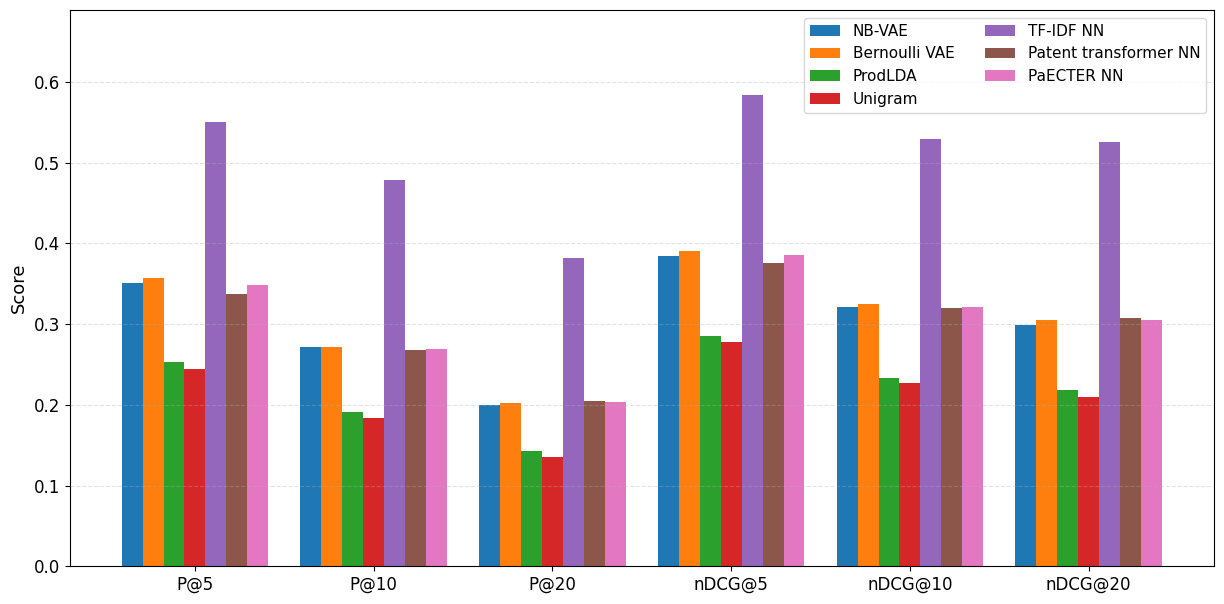

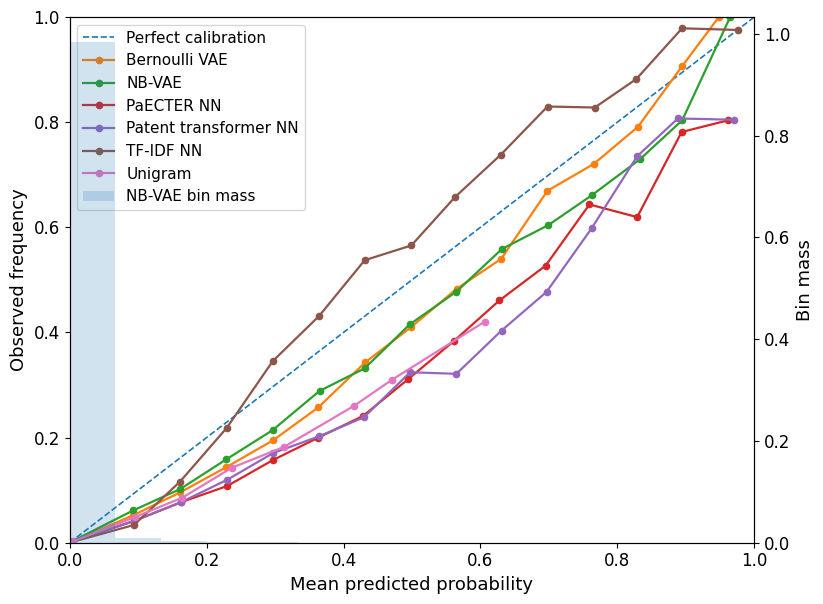

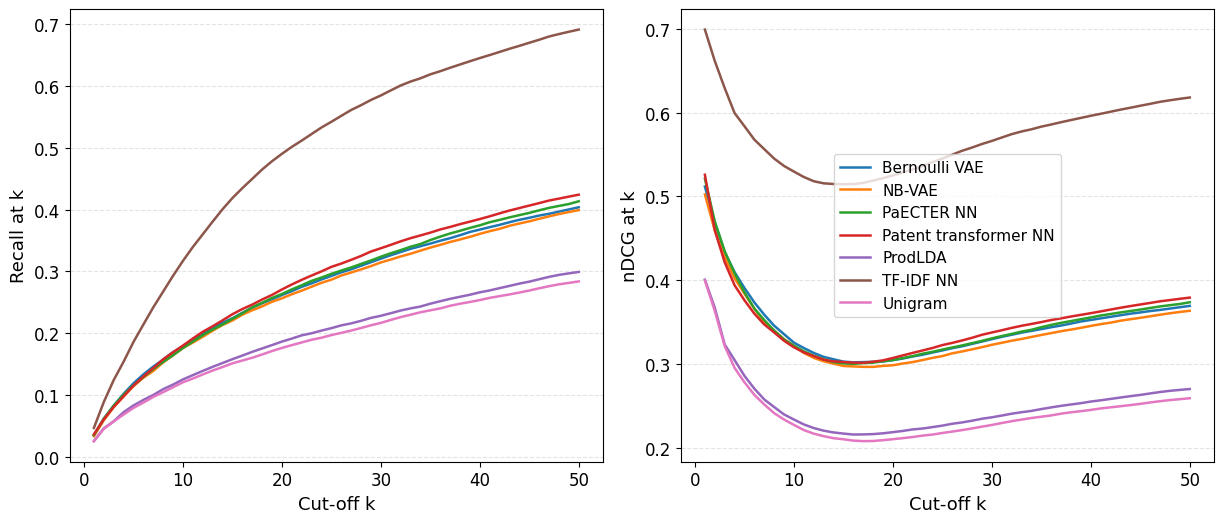

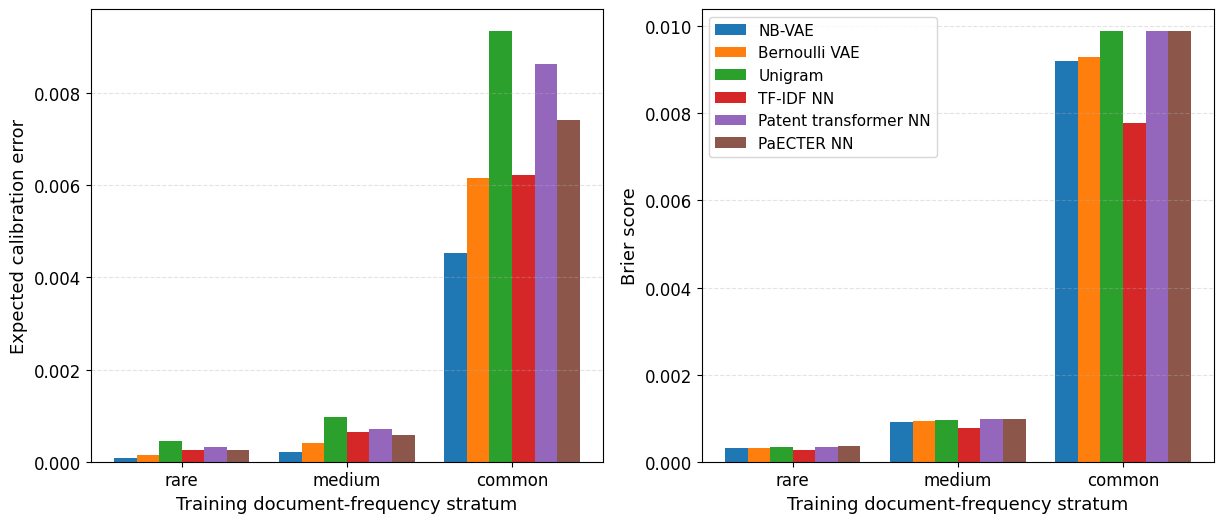

In [ ]:
def plot_completion_metrics(df: pd.DataFrame, out_path: str):
    metrics = ['P@5', 'P@10', 'P@20', 'nDCG@5', 'nDCG@10', 'nDCG@20']
    available = [m for m in metrics if m in df.columns]
    labels = df['model'].tolist()
    x = np.arange(len(available))
    width = 0.82 / max(1, len(labels))
    fig, ax = plt.subplots(figsize=(12.4, 6.2))
    for j, (_, row) in enumerate(df.iterrows()):
        vals = [row[m] for m in available]
        ax.bar(x + (j - (len(labels)-1)/2) * width, vals, width=width, label=short_name(row['model']))
    ax.set_xticks(x)
    ax.set_xticklabels(available, rotation=0)
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(0.05, np.nanmax(df[available].values) * 1.18))
    ax.legend(fontsize=FIG_LEGEND_SIZE, ncol=2, frameon=True)
    style_axis(ax, grid_axis='y')
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_calibration_bins(bins_df: pd.DataFrame, out_path: str):
    fig, ax1 = plt.subplots(figsize=(8.4, 6.2))
    ax1.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, label='Perfect calibration')
    for model_name, group in bins_df.groupby('model'):
        g = group.dropna(subset=['freq'])
        if g.empty:
            continue
        ax1.plot(g['conf'], g['freq'], marker='o', markersize=4.5, linewidth=1.6, label=short_name(model_name))
    ax1.set_xlabel('Mean predicted probability')
    ax1.set_ylabel('Observed frequency')
    max_conf = bins_df['conf'].max(skipna=True) if not bins_df.empty else 1.0
    max_freq = bins_df['freq'].max(skipna=True) if not bins_df.empty else 1.0
    ax1.set_xlim(0, min(1.0, max(0.05, max_conf * 1.2)))
    ax1.set_ylim(0, min(1.0, max(0.05, max_freq * 1.2)))
    style_axis(ax1)
    ax2 = ax1.twinx()
    nb_bins = bins_df[bins_df['model'].eq('NB-to-Bernoulli VAE')]
    if not nb_bins.empty:
        ax2.bar(nb_bins['mid'], nb_bins['mass'], width=1/15, alpha=0.20, label='NB-VAE bin mass')
    ax2.set_ylabel('Bin mass')
    style_axis(ax2)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def evaluate_completion_curve(scores: np.ndarray, X_obs: sp.csr_matrix, X_hold: sp.csr_matrix, model_name: str, curve_ks: Tuple[int, ...] = CURVE_KS) -> pd.DataFrame:
    """Compute P@k, R@k and nDCG@k for many k values using stable ranking ties."""
    scores = np.asarray(scores, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    max_k = max(curve_ks)
    accum = {k: {'P': [], 'R': [], 'nDCG': []} for k in curve_ks}
    for i in range(scores.shape[0]):
        held_idx = X_hold.getrow(i).indices
        if held_idx.size == 0:
            continue
        obs_idx = X_obs.getrow(i).indices
        rank_scores = scores[i].copy()
        rank_scores[obs_idx] = -np.inf
        order = np.argsort(-rank_scores, kind='mergesort')[:max_k]
        gains = np.isin(order, held_idx).astype(np.float64)
        total_pos = held_idx.size
        cumsum = np.cumsum(gains)
        discounts = 1.0 / np.log2(np.arange(2, max_k + 2))
        dcg_cumsum = np.cumsum(gains * discounts)
        for k in curve_ks:
            ideal_len = min(k, total_pos)
            ideal = np.sum(1.0 / np.log2(np.arange(2, ideal_len + 2))) if ideal_len > 0 else 0.0
            accum[k]['P'].append(float(cumsum[k-1] / k))
            accum[k]['R'].append(float(cumsum[k-1] / total_pos))
            accum[k]['nDCG'].append(float(dcg_cumsum[k-1] / ideal if ideal > 0 else 0.0))
    rows = []
    for k in curve_ks:
        rows.append({
            'model': model_name,
            'k': k,
            'P@k': float(np.mean(accum[k]['P'])) if accum[k]['P'] else np.nan,
            'R@k': float(np.mean(accum[k]['R'])) if accum[k]['R'] else np.nan,
            'nDCG@k': float(np.mean(accum[k]['nDCG'])) if accum[k]['nDCG'] else np.nan,
        })
    return pd.DataFrame(rows)


def plot_completion_curves(curve_df: pd.DataFrame, out_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True)
    for model_name, group in curve_df.groupby('model'):
        g = group.sort_values('k')
        axes[0].plot(g['k'], g['R@k'], linewidth=1.8, label=short_name(model_name))
        axes[1].plot(g['k'], g['nDCG@k'], linewidth=1.8, label=short_name(model_name))
    axes[0].set_xlabel('Cut-off k')
    axes[0].set_ylabel('Recall at k')
    axes[1].set_xlabel('Cut-off k')
    axes[1].set_ylabel('nDCG at k')
    for ax in axes:
        style_axis(ax, grid_axis='y')
    axes[1].legend(fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def collect_unobserved_by_frequency(probs: np.ndarray, X_obs: sp.csr_matrix, X_hold: sp.csr_matrix, term_strata: np.ndarray, model_name: str, n_bins: int = 15) -> pd.DataFrame:
    """Compute calibration metrics separately for rare, medium and common training terms."""
    probs = np.asarray(probs, dtype=np.float64)
    X_obs = X_obs.tocsr(); X_hold = X_hold.tocsr()
    strata_names = pd.Series(term_strata).dropna().unique().tolist()
    rows = []
    V = probs.shape[1]
    for stratum in strata_names:
        all_p, all_y = [], []
        stratum_mask = (term_strata == stratum)
        for i in range(probs.shape[0]):
            if X_hold.getrow(i).nnz == 0:
                continue
            obs_idx = X_obs.getrow(i).indices
            mask = stratum_mask.copy()
            mask[obs_idx] = False
            if not mask.any():
                continue
            y = np.zeros(V, dtype=np.float32)
            y[X_hold.getrow(i).indices] = 1.0
            all_p.append(probs[i, mask])
            all_y.append(y[mask])
        if not all_p:
            continue
        p = np.clip(np.concatenate(all_p), 0.0, 1.0)
        y = np.concatenate(all_y)
        bins = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (p >= lo) & ((p < hi) if b < n_bins - 1 else (p <= hi))
            if m.sum() == 0:
                continue
            ece += float(m.mean()) * abs(float(y[m].mean()) - float(p[m].mean()))
        rows.append({
            'model': model_name,
            'frequency_stratum': stratum,
            'ECE': float(ece),
            'Brier': float(np.mean((p - y) ** 2)),
            'positive_rate': float(y.mean()),
            'evaluated_pairs': int(p.size),
        })
    return pd.DataFrame(rows)


def plot_frequency_calibration(strata_df: pd.DataFrame, out_path: str):
    if strata_df.empty:
        return
    order = ['rare', 'medium', 'common']
    strata = [s for s in order if s in strata_df['frequency_stratum'].unique()]
    models = [m for m in completion_df['model'].tolist() if m in strata_df['model'].unique()]
    x = np.arange(len(strata))
    width = 0.82 / max(1, len(models))
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.4), sharex=True)
    for j, model_name in enumerate(models):
        subset = strata_df[strata_df['model'].eq(model_name)]
        for ax, metric in zip(axes, ['ECE', 'Brier']):
            vals = []
            for s in strata:
                row = subset[subset['frequency_stratum'].eq(s)]
                vals.append(float(row[metric].iloc[0]) if not row.empty else np.nan)
            ax.bar(x + (j - (len(models)-1)/2) * width, vals, width=width, label=short_name(model_name))
    axes[0].set_ylabel('Expected calibration error')
    axes[1].set_ylabel('Brier score')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(strata)
        ax.set_xlabel('Training document-frequency stratum')
        style_axis(ax, grid_axis='y')
    axes[1].legend(fontsize=FIG_LEGEND_SIZE, ncol=1, frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

# Main manuscript figures.
plot_completion_metrics(completion_df, os.path.join(FIG_DIR, 'completion_metrics_models.png'))
plot_calibration_bins(calibration_bins_df, os.path.join(FIG_DIR, 'calibration_reliability_models.png'))

# Additional Figure A: rank-recovery curves across cut-offs.
curve_models = [m for m in completion_df['model'].tolist() if m in test_score_cache]
completion_curve_df = pd.concat(
    [evaluate_completion_curve(test_score_cache[m], X_test_obs, X_test_hold, m) for m in curve_models],
    ignore_index=True,
)
completion_curve_df.to_csv(os.path.join(TABLE_DIR, 'completion_rank_curves.csv'), index=False)
plot_completion_curves(completion_curve_df, os.path.join(FIG_DIR, 'completion_rank_curves.png'))

# Additional Figure B: calibration by training document-frequency stratum.
term_counts = np.asarray(X_train.sum(axis=0)).ravel()
try:
    term_strata = np.asarray(pd.qcut(term_counts, q=3, labels=['rare', 'medium', 'common'], duplicates='drop').astype(str))
except Exception:
    # Fallback if there are too many tied counts for qcut.
    tertiles = np.quantile(term_counts, [1/3, 2/3])
    term_strata = np.where(term_counts <= tertiles[0], 'rare', np.where(term_counts <= tertiles[1], 'medium', 'common'))
calibration_models_for_strata = [m for m in completion_df['model'].tolist() if m in test_score_cache and m != 'ProdLDA']
strata_calibration_df = pd.concat(
    [collect_unobserved_by_frequency(test_score_cache[m], X_test_obs, X_test_hold, term_strata, m) for m in calibration_models_for_strata],
    ignore_index=True,
)
strata_calibration_df.to_csv(os.path.join(TABLE_DIR, 'frequency_stratified_calibration.csv'), index=False)
plot_frequency_calibration(strata_calibration_df, os.path.join(FIG_DIR, 'calibration_by_frequency_stratum.png'))


## 13. Conditional posterior-predictive assessment

This section implements the approximate conditional predictive check for the two fitted VAE variants. It uses exactly the eligible test documents and fixed seed-12 completion mask used above.

For every draw and document, it samples

\[
z_i^{(s)}\sim q_\phi(z_i\mid x_i^{\mathrm{obs}}),\qquad
x_{iv}^{\mathrm{rep},(s)}\sim\mathrm{Bernoulli}(\pi_{iv}(z_i^{(s)}))
\]

for every non-revealed coordinate. Revealed positive entries remain fixed and are excluded from the reported sparsity summaries. For the NB-derived model, drawing a Bernoulli indicator with probability \(1-\rho^\alpha\) is exactly equivalent to drawing the latent negative binomial count and recording whether it exceeds zero.

The check compares (i) unobserved positive-term counts per document and (ii) masked marginal document frequencies per term. It reports predictive means, 90%/95% intervals, interval-inclusion rates, bias/error, correlations, a manuscript-ready table and a two-by-two appendix figure. The intervals condition on the fitted weights, split and mask, i.e. they are neither confidence intervals nor simultaneous term level intervals. This is a conditional sparsity check, not a general proof of model fit.


In [ ]:
def sha256_sparse_csr(matrix: sp.csr_matrix) -> str:
    matrix = matrix.tocsr()
    digest = hashlib.sha256()
    digest.update(np.asarray(matrix.shape, dtype=np.int64).tobytes())
    digest.update(matrix.indptr.astype(np.int64, copy=False).tobytes())
    digest.update(matrix.indices.astype(np.int64, copy=False).tobytes())
    digest.update(matrix.data.astype(np.float32, copy=False).tobytes())
    return digest.hexdigest()


def sha256_model_state(model: nn.Module) -> str:
    digest = hashlib.sha256()
    for name, tensor in sorted(model.state_dict().items()):
        array = tensor.detach().cpu().contiguous().numpy()
        digest.update(name.encode('utf-8'))
        digest.update(str(array.dtype).encode('ascii'))
        digest.update(np.asarray(array.shape, dtype=np.int64).tobytes())
        digest.update(array.tobytes())
    return digest.hexdigest()


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() < 3 or np.unique(x[finite]).size < 2 or np.unique(y[finite]).size < 2:
        return np.nan
    return float(spearmanr(x[finite], y[finite]).statistic)


def decode_presence_probabilities(model: nn.Module, latent: torch.Tensor) -> torch.Tensor:
    if isinstance(model, NBPresenceVAE):
        probabilities, _ = model.decode_pi(latent)
        return probabilities
    if isinstance(model, BernoulliVAE):
        logits = model.logit_head(model.decoder(latent))
        return torch.sigmoid(logits).clamp(min=1e-7, max=1.0 - 1e-7)
    raise TypeError(f"Conditional PPC is only defined for the two VAE variants, not {type(model).__name__}")


def conditional_posterior_predictive_draws(
    model: nn.Module,
    model_name: str,
    X_obs: sp.csr_matrix,
    X_hold: sp.csr_matrix,
    n_draws: int,
    seed: int,
    doc_batch_size: int,
    draw_batch_size: int,
    reuse_matching_cache: bool = False,
) -> Dict[str, object]:
    """Stream latent and Bernoulli draws; retain only document/term summaries."""
    eligible = np.asarray(X_hold.sum(axis=1)).ravel() > 0
    eligible_indices = np.flatnonzero(eligible).astype(np.int32)
    X_obs_eval = X_obs[eligible].tocsr().astype(np.float32)
    X_hold_eval = X_hold[eligible].tocsr().astype(np.float32)
    if X_obs_eval.shape[0] == 0:
        raise ValueError("No eligible documents have held-out terms.")

    observed_doc_counts = np.asarray(X_hold_eval.sum(axis=1)).ravel().astype(np.int32)
    observed_term_df = np.asarray(X_hold_eval.sum(axis=0)).ravel().astype(np.int32)
    revealed_doc_counts = np.asarray(X_obs_eval.sum(axis=1)).ravel().astype(np.int32)
    mask_exposure = (X_obs_eval.shape[0] - np.asarray(X_obs_eval.sum(axis=0)).ravel()).astype(np.int32)
    if int(observed_doc_counts.sum()) != int(observed_term_df.sum()):
        raise AssertionError("Observed held-out totals disagree between document and term margins.")

    state_sha = sha256_model_state(model)
    signature_payload = {
        'protocol_version': 2,
        'model_name': model_name,
        'model_state_sha256': state_sha,
        'observed_mask_sha256': sha256_sparse_csr(X_obs_eval),
        'heldout_mask_sha256': sha256_sparse_csr(X_hold_eval),
        'n_draws': int(n_draws),
        'seed': int(seed),
        'doc_batch_size': int(doc_batch_size),
        'draw_batch_size': int(draw_batch_size),
        'device': str(DEVICE),
        'model_parameter_dtype': str(next(model.parameters()).dtype),
        'eligible_documents': int(X_obs_eval.shape[0]),
        'vocabulary_size': int(X_obs_eval.shape[1]),
        'vocabulary_sha256': hashlib.sha256(
            '\n'.join(vocab.tolist()).encode('utf-8')
        ).hexdigest(),
    }
    signature = hashlib.sha256(
        json.dumps(signature_payload, sort_keys=True).encode('utf-8')
    ).hexdigest()
    safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
    cache_path = Path(SIM_DIR) / f'conditional_ppc_raw_{safe_name}.npz'

    if reuse_matching_cache and cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        cached_signature = str(cached['signature'].item())
        if cached_signature == signature:
            print(f"Loading matching conditional-PPC cache: {cache_path.name}")
            return {
                'model_name': model_name,
                'doc_count_draws': cached['doc_count_draws'],
                'term_df_draws': cached['term_df_draws'],
                'decoder_expected_total_draws': cached['decoder_expected_total_draws'],
                'eligible_indices': cached['eligible_indices'],
                'observed_doc_counts': cached['observed_doc_counts'],
                'observed_term_df': cached['observed_term_df'],
                'revealed_doc_counts': cached['revealed_doc_counts'],
                'mask_exposure': cached['mask_exposure'],
                'model_state_sha256': state_sha,
                'signature': signature,
                'runtime_seconds': float(cached['runtime_seconds'].item()),
                'cache_path': str(cache_path),
            }
        print(f"Ignoring non-matching conditional-PPC cache: {cache_path.name}")

    n_documents, vocabulary_size = X_obs_eval.shape
    if vocabulary_size > np.iinfo(np.int16).max or n_documents > np.iinfo(np.int16).max:
        raise ValueError("int16 draw storage is unsafe for the current dimensions.")
    doc_count_draws = np.empty((n_draws, n_documents), dtype=np.int16)
    term_df_draws = np.empty((n_draws, vocabulary_size), dtype=np.int16)
    decoder_expected_total_draws = np.empty(n_draws, dtype=np.float64)
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    model = model.to(DEVICE)
    model.eval()
    started = time.perf_counter()

    with torch.inference_mode():
        for draw_start in tqdm(
            range(0, n_draws, draw_batch_size),
            desc=f'Conditional PPC: {model_name}',
        ):
            current_draws = min(draw_batch_size, n_draws - draw_start)
            term_block = np.zeros((current_draws, vocabulary_size), dtype=np.int32)
            expected_total_block = np.zeros(current_draws, dtype=np.float64)
            for doc_start in range(0, n_documents, doc_batch_size):
                doc_stop = min(doc_start + doc_batch_size, n_documents)
                observed_batch = torch.from_numpy(
                    X_obs_eval[doc_start:doc_stop].toarray().astype(np.float32)
                ).to(DEVICE)
                posterior_mean, posterior_logvar = model.encoder(observed_batch)
                posterior_sd = torch.exp(0.5 * posterior_logvar)
                noise = torch.randn(
                    (current_draws, observed_batch.shape[0], posterior_mean.shape[1]),
                    generator=generator,
                    device=DEVICE,
                    dtype=posterior_mean.dtype,
                )
                latent = posterior_mean.unsqueeze(0) + posterior_sd.unsqueeze(0) * noise
                probabilities = decode_presence_probabilities(
                    model, latent.reshape(-1, posterior_mean.shape[1])
                ).reshape(current_draws, observed_batch.shape[0], vocabulary_size)
                if not torch.isfinite(probabilities).all():
                    raise FloatingPointError(f"{model_name}: decoder produced non-finite probabilities")
                if torch.any(probabilities < 0) or torch.any(probabilities > 1):
                    raise FloatingPointError(f"{model_name}: decoder probabilities are outside [0, 1]")
                uniforms = torch.rand(
                    probabilities.shape,
                    generator=generator,
                    device=DEVICE,
                    dtype=probabilities.dtype,
                )
                # Revealed positives are conceptually clamped to one. Only the
                # complementary mask is sampled and summarized here.
                unobserved_mask = observed_batch.eq(0).unsqueeze(0)
                expected_total_block += (
                    probabilities * unobserved_mask
                ).sum(dim=(1, 2)).cpu().numpy().astype(np.float64)
                sampled_unobserved = uniforms.lt(probabilities) & unobserved_mask
                document_counts = sampled_unobserved.sum(dim=2).cpu().numpy().astype(np.int16)
                doc_count_draws[
                    draw_start:draw_start + current_draws, doc_start:doc_stop
                ] = document_counts
                term_block += sampled_unobserved.sum(dim=1).cpu().numpy().astype(np.int32)
                del probabilities, uniforms, sampled_unobserved, latent, noise
            term_df_draws[draw_start:draw_start + current_draws] = term_block.astype(np.int16)
            sampled_document_totals = doc_count_draws[
                draw_start:draw_start + current_draws
            ].astype(np.int64).sum(axis=1)
            sampled_term_totals = term_block.astype(np.int64).sum(axis=1)
            if not np.array_equal(sampled_document_totals, sampled_term_totals):
                raise AssertionError(f"{model_name}: sampled document and term margins disagree")
            decoder_expected_total_draws[
                draw_start:draw_start + current_draws
            ] = expected_total_block

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    runtime_seconds = time.perf_counter() - started
    sampled_total_draws = doc_count_draws.astype(np.int64).sum(axis=1)
    maximum_document_counts = (
        vocabulary_size - revealed_doc_counts.astype(np.int64)
    )[None, :]
    if np.any(doc_count_draws.astype(np.int64) > maximum_document_counts):
        raise AssertionError(f"{model_name}: a document draw exceeds its non-revealed exposure")
    if np.any(term_df_draws.astype(np.int64) > mask_exposure.astype(np.int64)[None, :]):
        raise AssertionError(f"{model_name}: a term-frequency draw exceeds its masked exposure")
    if np.var(sampled_total_draws) <= 0:
        raise AssertionError(f"{model_name}: posterior-predictive totals have no Monte Carlo variation")
    total_residuals = sampled_total_draws.astype(np.float64) - decoder_expected_total_draws
    residual_standard_error = float(total_residuals.std(ddof=1) / np.sqrt(n_draws))
    if abs(float(total_residuals.mean())) > max(6.0 * residual_standard_error, 1e-8):
        raise AssertionError(
            f"{model_name}: the sampled-minus-expected total mean exceeds six Monte Carlo SEs"
        )
    temporary_cache_path = cache_path.with_suffix(cache_path.suffix + '.tmp.npz')
    np.savez_compressed(
        temporary_cache_path,
        doc_count_draws=doc_count_draws,
        term_df_draws=term_df_draws,
        decoder_expected_total_draws=decoder_expected_total_draws,
        eligible_indices=eligible_indices,
        observed_doc_counts=observed_doc_counts,
        observed_term_df=observed_term_df,
        revealed_doc_counts=revealed_doc_counts,
        mask_exposure=mask_exposure,
        signature=np.asarray(signature),
        runtime_seconds=np.asarray(runtime_seconds, dtype=np.float64),
    )
    os.replace(temporary_cache_path, cache_path)
    return {
        'model_name': model_name,
        'doc_count_draws': doc_count_draws,
        'term_df_draws': term_df_draws,
        'decoder_expected_total_draws': decoder_expected_total_draws,
        'eligible_indices': eligible_indices,
        'observed_doc_counts': observed_doc_counts,
        'observed_term_df': observed_term_df,
        'revealed_doc_counts': revealed_doc_counts,
        'mask_exposure': mask_exposure,
        'model_state_sha256': state_sha,
        'signature': signature,
        'runtime_seconds': runtime_seconds,
        'cache_path': str(cache_path),
    }


def summarize_conditional_ppc(result: Dict[str, object]) -> Tuple[Dict[str, object], pd.DataFrame, pd.DataFrame]:
    model_name = str(result['model_name'])
    doc_draws = np.asarray(result['doc_count_draws'], dtype=np.float64)
    term_draws = np.asarray(result['term_df_draws'], dtype=np.float64)
    observed_doc = np.asarray(result['observed_doc_counts'], dtype=np.float64)
    observed_term = np.asarray(result['observed_term_df'], dtype=np.float64)
    revealed_doc = np.asarray(result['revealed_doc_counts'], dtype=np.int32)
    exposure = np.asarray(result['mask_exposure'], dtype=np.float64)
    expected_total_draws = np.asarray(result['decoder_expected_total_draws'], dtype=np.float64)

    doc_mean = doc_draws.mean(axis=0)
    doc_median = np.median(doc_draws, axis=0)
    doc_q025, doc_q05, doc_q95, doc_q975 = np.quantile(
        doc_draws, [0.025, 0.05, 0.95, 0.975], axis=0
    )
    term_mean = term_draws.mean(axis=0)
    term_median = np.median(term_draws, axis=0)
    term_q025, term_q05, term_q95, term_q975 = np.quantile(
        term_draws, [0.025, 0.05, 0.95, 0.975], axis=0
    )
    draw_mean_counts = doc_draws.mean(axis=1)
    draw_total_counts = doc_draws.sum(axis=1)
    observed_total = float(observed_doc.sum())
    valid_terms = exposure > 0
    zero_term_draws = (term_draws[:, valid_terms] == 0).sum(axis=1)

    summary = {
        'model': model_name,
        'eligible_documents': int(observed_doc.size),
        'posterior_predictive_draws': int(doc_draws.shape[0]),
        'observed_mean_unobserved_positives_per_document': float(observed_doc.mean()),
        'predictive_mean_unobserved_positives_per_document': float(draw_mean_counts.mean()),
        'predictive_mean_count_q025': float(np.quantile(draw_mean_counts, 0.025)),
        'predictive_mean_count_q975': float(np.quantile(draw_mean_counts, 0.975)),
        'mean_count_bias': float(doc_mean.mean() - observed_doc.mean()),
        'mean_count_relative_bias': float((doc_mean.mean() - observed_doc.mean()) / observed_doc.mean()),
        'observed_total_unobserved_positives': int(observed_total),
        'predictive_total_unobserved_positives_mean': float(draw_total_counts.mean()),
        'predictive_total_q025': float(np.quantile(draw_total_counts, 0.025)),
        'predictive_total_q975': float(np.quantile(draw_total_counts, 0.975)),
        'predictive_to_observed_total_ratio': float(draw_total_counts.mean() / observed_total),
        'decoder_expected_total_mean': float(expected_total_draws.mean()),
        'sampled_minus_decoder_expected_total': float(draw_total_counts.mean() - expected_total_draws.mean()),
        'sampled_minus_decoder_expected_total_mcse': float(
            (draw_total_counts - expected_total_draws).std(ddof=1) / np.sqrt(doc_draws.shape[0])
        ),
        'document_count_mae': float(np.mean(np.abs(doc_mean - observed_doc))),
        'document_count_rmse': float(np.sqrt(np.mean((doc_mean - observed_doc) ** 2))),
        'document_count_spearman': safe_spearman(observed_doc, doc_mean),
        'document_count_90pct_interval_inclusion': float(np.mean((observed_doc >= doc_q05) & (observed_doc <= doc_q95))),
        'document_count_95pct_interval_inclusion': float(np.mean((observed_doc >= doc_q025) & (observed_doc <= doc_q975))),
        'masked_term_df_mae': float(np.mean(np.abs(term_mean[valid_terms] - observed_term[valid_terms]))),
        'masked_term_df_rmse': float(np.sqrt(np.mean((term_mean[valid_terms] - observed_term[valid_terms]) ** 2))),
        'masked_term_df_spearman': safe_spearman(observed_term[valid_terms], term_mean[valid_terms]),
        'masked_term_rate_mae': float(np.mean(np.abs(
            term_mean[valid_terms] / exposure[valid_terms] - observed_term[valid_terms] / exposure[valid_terms]
        ))),
        'masked_term_df_90pct_interval_inclusion': float(np.mean(
            (observed_term[valid_terms] >= term_q05[valid_terms]) &
            (observed_term[valid_terms] <= term_q95[valid_terms])
        )),
        'masked_term_df_95pct_interval_inclusion': float(np.mean(
            (observed_term[valid_terms] >= term_q025[valid_terms]) &
            (observed_term[valid_terms] <= term_q975[valid_terms])
        )),
        'observed_zero_masked_df_terms': int(np.sum(observed_term[valid_terms] == 0)),
        'predictive_zero_masked_df_terms_mean': float(zero_term_draws.mean()),
        'predictive_zero_masked_df_terms_q025': float(np.quantile(zero_term_draws, 0.025)),
        'predictive_zero_masked_df_terms_q975': float(np.quantile(zero_term_draws, 0.975)),
        'runtime_seconds': float(result['runtime_seconds']),
        'model_state_sha256': str(result['model_state_sha256']),
        'simulation_signature': str(result['signature']),
    }

    document_table = pd.DataFrame({
        'model': model_name,
        'test_row_index': np.asarray(result['eligible_indices'], dtype=np.int32),
        'revealed_positive_terms': revealed_doc,
        'observed_unobserved_positive_terms': observed_doc.astype(np.int32),
        'predictive_mean': doc_mean,
        'predictive_median': doc_median,
        'predictive_q025': doc_q025,
        'predictive_q05': doc_q05,
        'predictive_q95': doc_q95,
        'predictive_q975': doc_q975,
        'observed_inside_90pct_interval': (observed_doc >= doc_q05) & (observed_doc <= doc_q95),
        'observed_inside_95pct_interval': (observed_doc >= doc_q025) & (observed_doc <= doc_q975),
    })

    safe_exposure = np.where(exposure > 0, exposure, np.nan)
    term_table = pd.DataFrame({
        'model': model_name,
        'vocabulary_index': np.arange(observed_term.size, dtype=np.int32),
        'term': vocab,
        'training_document_frequency': np.asarray(X_train.sum(axis=0)).ravel().astype(np.int32),
        'training_frequency_stratum': term_strata,
        'masked_document_exposure': exposure.astype(np.int32),
        'observed_masked_document_frequency': observed_term.astype(np.int32),
        'observed_masked_rate': observed_term / safe_exposure,
        'predictive_mean_document_frequency': term_mean,
        'predictive_median_document_frequency': term_median,
        'predictive_q025': term_q025,
        'predictive_q05': term_q05,
        'predictive_q95': term_q95,
        'predictive_q975': term_q975,
        'predictive_mean_masked_rate': term_mean / safe_exposure,
        'observed_inside_90pct_interval': (observed_term >= term_q05) & (observed_term <= term_q95),
        'observed_inside_95pct_interval': (observed_term >= term_q025) & (observed_term <= term_q975),
    })
    return summary, document_table, term_table


In [ ]:
if not RUN_CONDITIONAL_PPC:
    raise RuntimeError("RUN_CONDITIONAL_PPC must be True for the manuscript revision run.")
if SIMULATION_DRAWS < 500:
    raise RuntimeError("The manuscript bundle requires at least 500 conditional-PPC draws per model.")

PPC_MODEL_MAP = {
    'NB-to-Bernoulli VAE': neural_models['NB-to-Bernoulli VAE'],
    'Direct Bernoulli VAE': neural_models['Direct Bernoulli VAE'],
}
ppc_latent_dimensions = {
    int(model.encoder.mu.out_features) for model in PPC_MODEL_MAP.values()
}
if len(ppc_latent_dimensions) != 1:
    raise AssertionError(
        "Common-random-number comparison requires the two VAE posteriors to have the same latent dimension."
    )
conditional_ppc_results: Dict[str, Dict[str, object]] = {}
conditional_ppc_summary_rows = []
conditional_ppc_document_tables = []
conditional_ppc_term_tables = []

for ppc_model_name, ppc_model in PPC_MODEL_MAP.items():
    ppc_result = conditional_posterior_predictive_draws(
        model=ppc_model,
        model_name=ppc_model_name,
        X_obs=X_test_obs,
        X_hold=X_test_hold,
        n_draws=SIMULATION_DRAWS,
        seed=SIMULATION_SEED,  # common random numbers across the two VAE checks
        doc_batch_size=SIMULATION_DOC_BATCH_SIZE,
        draw_batch_size=SIMULATION_DRAW_BATCH_SIZE,
        reuse_matching_cache=REUSE_MATCHING_SIMULATION_CACHE,
    )
    summary_row, document_table, term_table = summarize_conditional_ppc(ppc_result)
    conditional_ppc_results[ppc_model_name] = ppc_result
    conditional_ppc_summary_rows.append(summary_row)
    conditional_ppc_document_tables.append(document_table)
    conditional_ppc_term_tables.append(term_table)

conditional_ppc_summary_df = pd.DataFrame(conditional_ppc_summary_rows)
conditional_ppc_documents_df = pd.concat(conditional_ppc_document_tables, ignore_index=True)
conditional_ppc_terms_df = pd.concat(conditional_ppc_term_tables, ignore_index=True)
conditional_ppc_summary_df['masked_term_rate_mae_per_1000'] = (
    1000.0 * conditional_ppc_summary_df['masked_term_rate_mae']
)

frequency_stratum_rows = []
for ppc_model_name, ppc_result in conditional_ppc_results.items():
    term_draws = np.asarray(ppc_result['term_df_draws'], dtype=np.float64)
    observed_term = np.asarray(ppc_result['observed_term_df'], dtype=np.float64)
    exposure = np.asarray(ppc_result['mask_exposure'], dtype=np.float64)
    for frequency_stratum in ['rare', 'medium', 'common']:
        selected_terms = np.asarray(term_strata == frequency_stratum) & (exposure > 0)
        if not selected_terms.any():
            continue
        predictive_mean = term_draws[:, selected_terms].mean(axis=0)
        observed_rates = observed_term[selected_terms] / exposure[selected_terms]
        predictive_rates = predictive_mean / exposure[selected_terms]
        lower, upper = np.quantile(
            term_draws[:, selected_terms], [0.025, 0.975], axis=0
        )
        zero_terms_per_draw = (term_draws[:, selected_terms] == 0).sum(axis=1)
        frequency_stratum_rows.append({
            'model': ppc_model_name,
            'training_frequency_stratum': frequency_stratum,
            'terms': int(selected_terms.sum()),
            'observed_zero_masked_df_terms': int(np.sum(observed_term[selected_terms] == 0)),
            'predictive_zero_masked_df_terms_mean': float(zero_terms_per_draw.mean()),
            'predictive_zero_masked_df_terms_q025': float(np.quantile(zero_terms_per_draw, 0.025)),
            'predictive_zero_masked_df_terms_q975': float(np.quantile(zero_terms_per_draw, 0.975)),
            'masked_term_rate_mae_per_1000': float(1000.0 * np.mean(np.abs(predictive_rates - observed_rates))),
            'masked_term_df_spearman': safe_spearman(
                observed_term[selected_terms], predictive_mean
            ),
            'masked_term_df_95pct_interval_inclusion': float(np.mean(
                (observed_term[selected_terms] >= lower) &
                (observed_term[selected_terms] <= upper)
            )),
        })
conditional_ppc_by_frequency_df = pd.DataFrame(frequency_stratum_rows)

conditional_ppc_summary_df.to_csv(
    os.path.join(TABLE_DIR, 'conditional_ppc_summary.csv'), index=False
)
conditional_ppc_documents_df.to_csv(
    os.path.join(TABLE_DIR, 'conditional_ppc_document_counts.csv'), index=False
)
conditional_ppc_terms_df.to_csv(
    os.path.join(TABLE_DIR, 'conditional_ppc_term_frequencies.csv'), index=False
)
conditional_ppc_by_frequency_df.to_csv(
    os.path.join(TABLE_DIR, 'conditional_ppc_by_frequency_stratum.csv'), index=False
)
print(conditional_ppc_summary_df.to_string(index=False))
print(conditional_ppc_by_frequency_df.to_string(index=False))


Conditional PPC: NB-to-Bernoulli VAE:   0%|          | 0/125 [00:00<?, ?it/s]

Conditional PPC: Direct Bernoulli VAE:   0%|          | 0/125 [00:00<?, ?it/s]

               model  eligible_documents  posterior_predictive_draws  observed_mean_unobserved_positives_per_document  predictive_mean_unobserved_positives_per_document  predictive_mean_count_q025  predictive_mean_count_q975  mean_count_bias  mean_count_relative_bias  observed_total_unobserved_positives  predictive_total_unobserved_positives_mean  predictive_total_q025  predictive_total_q975  predictive_to_observed_total_ratio  decoder_expected_total_mean  sampled_minus_decoder_expected_total  sampled_minus_decoder_expected_total_mcse  document_count_mae  document_count_rmse  document_count_spearman  document_count_90pct_interval_inclusion  document_count_95pct_interval_inclusion  masked_term_df_mae  masked_term_df_rmse  masked_term_df_spearman  masked_term_rate_mae  masked_term_df_90pct_interval_inclusion  masked_term_df_95pct_interval_inclusion  observed_zero_masked_df_terms  predictive_zero_masked_df_terms_mean  predictive_zero_masked_df_terms_q025  predictive_zero_masked_df_terms_q

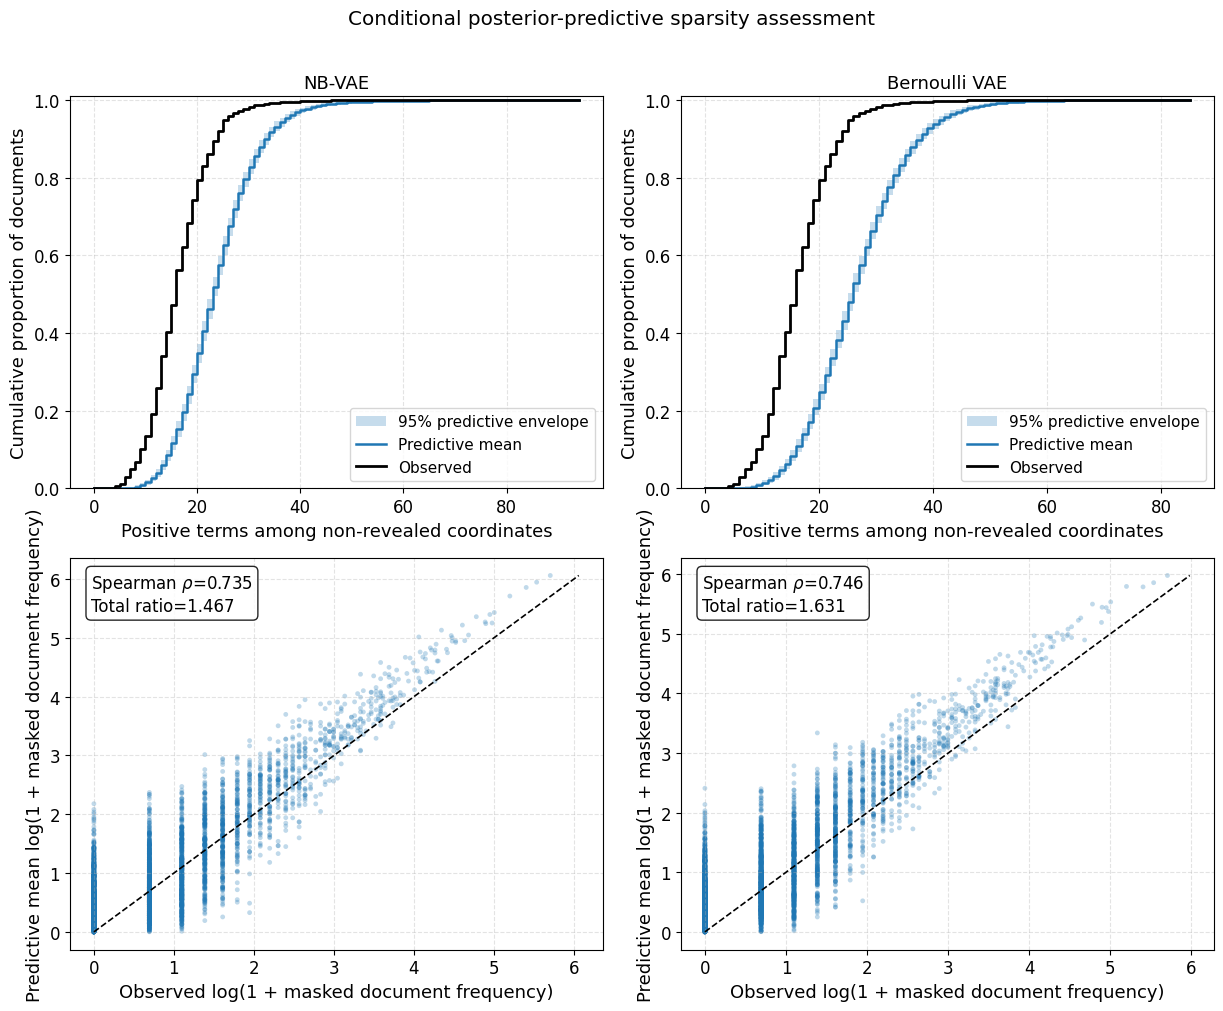

1497

In [ ]:
def write_conditional_ppc_latex(summary_df: pd.DataFrame, output_path: str) -> None:
    lines = [
        r'\begin{tabular}{lrrrrrrrrr}',
        r'\toprule',
        r'Model & $n$ & Draws & Observed mean & Predictive mean (95\% PI) & Total ratio & Doc. 95\% incl. & Term-rate MAE $\times 10^3$ & Term $\rho$ & Term 95\% incl. \\',
        r'\midrule',
    ]
    for _, row in summary_df.iterrows():
        model_label = 'NB-to-Bernoulli VAE' if row['model'] == 'NB-to-Bernoulli VAE' else 'Direct Bernoulli VAE'
        predictive_interval = (
            f"{row['predictive_mean_unobserved_positives_per_document']:.2f} "
            f"({row['predictive_mean_count_q025']:.2f}, {row['predictive_mean_count_q975']:.2f})"
        )
        lines.append(
            f"{model_label} & {int(row['eligible_documents']):,} & "
            f"{int(row['posterior_predictive_draws']):,} & "
            f"{row['observed_mean_unobserved_positives_per_document']:.2f} & "
            f"{predictive_interval} & "
            f"{row['predictive_to_observed_total_ratio']:.3f} & "
            f"{row['document_count_95pct_interval_inclusion']:.3f} & "
            f"{row['masked_term_rate_mae_per_1000']:.3f} & "
            f"{row['masked_term_df_spearman']:.3f} & "
            f"{row['masked_term_df_95pct_interval_inclusion']:.3f} \\\\"
        )
    lines.extend([r'\bottomrule', r'\end{tabular}'])
    Path(output_path).write_text('\n'.join(lines), encoding='utf-8')


write_conditional_ppc_latex(
    conditional_ppc_summary_df,
    os.path.join(TABLE_DIR, 'table_conditional_ppc_summary_tabular.tex'),
)

model_order = ['NB-to-Bernoulli VAE', 'Direct Bernoulli VAE']
fig, axes = plt.subplots(2, 2, figsize=(12.4, 10.0))
for column, model_name in enumerate(model_order):
    result = conditional_ppc_results[model_name]
    document_draws = np.asarray(result['doc_count_draws'], dtype=np.int32)
    observed_document_counts = np.asarray(result['observed_doc_counts'], dtype=np.int32)
    observed_term_df = np.asarray(result['observed_term_df'], dtype=np.float64)
    predictive_term_mean = np.asarray(result['term_df_draws'], dtype=np.float64).mean(axis=0)
    term_exposure = np.asarray(result['mask_exposure'], dtype=np.int32)
    summary_row = conditional_ppc_summary_df.loc[
        conditional_ppc_summary_df['model'].eq(model_name)
    ].iloc[0]

    upper_count = int(max(
        np.max(observed_document_counts) if observed_document_counts.size else 0,
        np.max(document_draws) if document_draws.size else 0,
    ))
    count_grid = np.arange(0, upper_count + 1)
    observed_ecdf = np.asarray([
        np.mean(observed_document_counts <= threshold) for threshold in count_grid
    ])
    predictive_ecdfs = np.column_stack([
        np.mean(document_draws <= threshold, axis=1) for threshold in count_grid
    ])
    predictive_ecdf_mean = predictive_ecdfs.mean(axis=0)
    predictive_ecdf_low, predictive_ecdf_high = np.quantile(
        predictive_ecdfs, [0.025, 0.975], axis=0
    )

    ax = axes[0, column]
    ax.fill_between(
        count_grid, predictive_ecdf_low, predictive_ecdf_high,
        step='post', alpha=0.25, label='95% predictive envelope'
    )
    ax.step(count_grid, predictive_ecdf_mean, where='post', linewidth=1.8, label='Predictive mean')
    ax.step(count_grid, observed_ecdf, where='post', linewidth=2.0, color='black', label='Observed')
    ax.set_title(short_name(model_name))
    ax.set_xlabel('Positive terms among non-revealed coordinates')
    ax.set_ylabel('Cumulative proportion of documents')
    ax.set_ylim(0, 1.01)
    style_axis(ax, grid_axis='both')
    ax.legend(frameon=True, loc='lower right')

    ax = axes[1, column]
    plotted_terms = term_exposure > 0
    x_values = np.log1p(observed_term_df[plotted_terms])
    y_values = np.log1p(predictive_term_mean[plotted_terms])
    ax.scatter(x_values, y_values, s=12, alpha=0.28, edgecolors='none')
    identity_max = float(max(
        np.max(x_values) if x_values.size else 0,
        np.max(y_values) if y_values.size else 0,
    ))
    ax.plot([0, identity_max], [0, identity_max], color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Observed log(1 + masked document frequency)')
    ax.set_ylabel('Predictive mean log(1 + masked document frequency)')
    ax.text(
        0.04, 0.96,
        f"Spearman $\\rho$={summary_row['masked_term_df_spearman']:.3f}\n"
        f"Total ratio={summary_row['predictive_to_observed_total_ratio']:.3f}",
        transform=ax.transAxes, va='top', ha='left',
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
    )
    style_axis(ax, grid_axis='both')

fig.suptitle('Conditional posterior-predictive sparsity assessment', y=1.01)
fig.tight_layout()
figure_png = os.path.join(FIG_DIR, 'conditional_posterior_predictive_sparsity.png')
figure_pdf = os.path.join(FIG_DIR, 'conditional_posterior_predictive_sparsity.pdf')
fig.savefig(figure_png, dpi=300, bbox_inches='tight')
fig.savefig(figure_pdf, bbox_inches='tight')
plt.show()

protocol_text = f"""# Conditional posterior-predictive assessment

- Test completion mask: the fixed seed-{SEED + 2} mask used for the main completion task.
- Eligible documents: documents with at least one held-out positive term (equivalently, at least two retained present terms before masking).
- Draws per fitted VAE: {SIMULATION_DRAWS}.
- Simulation seed: {SIMULATION_SEED}; the same random-number seed is used for both VAE variants.
- Latent draw: z ~ q_phi(z | x_observed), with fitted weights and dropout disabled.
- Observation draw: Bernoulli decoder draw on every non-revealed coordinate.
- Revealed entries: fixed at their observed value and excluded from sparsity summaries.
- Document statistic: number of positive terms over all non-revealed coordinates.
- Term statistic: marginal document frequency over the same fixed non-revealed cells; exposure is recorded per term.
- Intervals: pointwise 90% and 95% Monte Carlo posterior-predictive intervals.

The corruption mechanism deliberately hides positive terms, so it is outcome-dependent rather than a model of natural missingness. The encoder was trained on complete vectors and receives zero-filled partial vectors here. Intervals integrate latent and Bernoulli realization uncertainty conditional on fixed fitted weights, split and mask; they do not include training, parameter, split or mask uncertainty. This is an approximate conditional posterior-predictive check of sparsity reproduction, not a formal goodness-of-fit test or evidence of causal/general predictive validity.
"""
Path(SIM_DIR, 'conditional_ppc_protocol.md').write_text(
    textwrap.dedent(protocol_text).strip() + '\n', encoding='utf-8'
)


## 14. Supervised CPC-prefix classification evaluated as ranking

Each representation is passed to the same class balanced logistic regression, trained on the training split and ranked on the test split. The reported pretrained transformer representation is PaECTER using complete train/test abstracts and PaECTER specific validated caches. Average precision is primary because the CPC targets are imbalanced.


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

B01D53/04 train positives 2194 test positives 274
B01D53/62 train positives 2231 test positives 279
  target_prefix             representation     AUROC  Average precision  \
3     B01D53/04                 TF-IDF SVD  0.902336           0.795316   
4     B01D53/04                    PaECTER  0.917570           0.794522   
0     B01D53/04         NB-VAE latent mean  0.793204           0.642694   
1     B01D53/04  Bernoulli VAE latent mean  0.789402           0.615931   
2     B01D53/04  ProdLDA topic proportions  0.522714           0.267398   
9     B01D53/62                    PaECTER  0.836668           0.652174   
8     B01D53/62                 TF-IDF SVD  0.813943           0.622297   
6     B01D53/62  Bernoulli VAE latent mean  0.762673           0.529640   
5     B01D53/62         NB-VAE latent mean  0.731992           0.492045   
7     B01D53/62  ProdLDA topic proportions  0.608643           0.375357   

   P@100  test_positives  test_total  
3   0.94             274        106

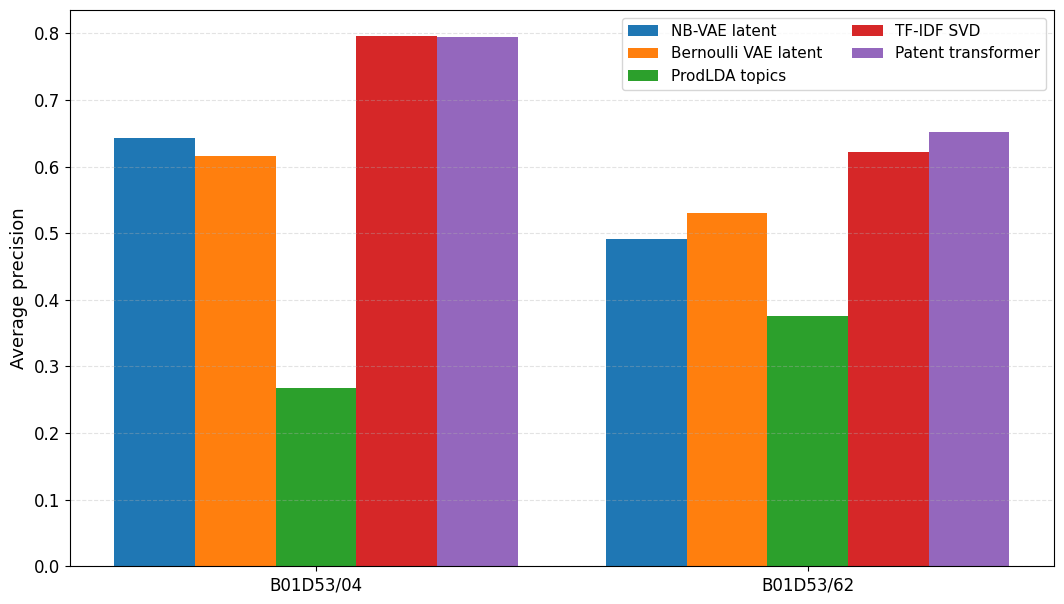

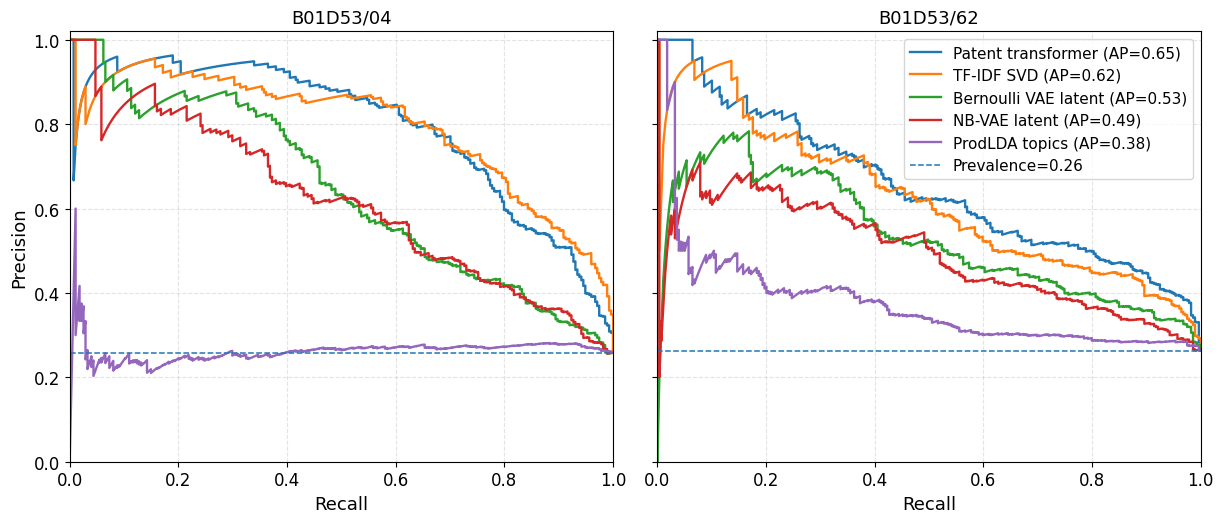

In [ ]:
def labels_for_split(split_name: str, prefix: str) -> np.ndarray:
    safe = prefix.replace('/', '_').replace('.', '_')
    column = f'label_{safe}'
    return splits[split_name][column].astype(int).to_numpy()


def eval_logistic_retrieval(Xtr, Xte, ytr, yte, representation: str, target_prefix: str) -> Optional[Tuple[Dict[str, float], np.ndarray]]:
    if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
        return None
    classifier = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='liblinear',
        random_state=SEED,
    )
    classifier.fit(Xtr, ytr)
    score = classifier.predict_proba(Xte)[:, 1]
    row = {
        'target_prefix': target_prefix,
        'representation': representation,
        'AUROC': float(roc_auc_score(yte, score)),
        'Average precision': float(average_precision_score(yte, score)),
        'P@100': precision_at_n(yte, score, n=100),
        'test_positives': int(yte.sum()),
        'test_total': int(len(yte)),
    }
    return row, np.asarray(score, dtype=np.float64)


# Full-document representations for train and test.
reprs_train = {}
reprs_test = {}
reprs_train['NB-VAE latent mean'] = encode_in_batches(
    neural_models['NB-to-Bernoulli VAE'], X_train_dense
)
reprs_test['NB-VAE latent mean'] = encode_in_batches(
    neural_models['NB-to-Bernoulli VAE'], X_test_dense
)
reprs_train['Bernoulli VAE latent mean'] = encode_in_batches(
    neural_models['Direct Bernoulli VAE'], X_train_dense
)
reprs_test['Bernoulli VAE latent mean'] = encode_in_batches(
    neural_models['Direct Bernoulli VAE'], X_test_dense
)
reprs_train['ProdLDA topic proportions'] = encode_in_batches(
    neural_models['ProdLDA'], X_train_dense
)
reprs_test['ProdLDA topic proportions'] = encode_in_batches(
    neural_models['ProdLDA'], X_test_dense
)

svd = TruncatedSVD(n_components=min(50, X_train_tfidf.shape[1] - 1), random_state=SEED)
reprs_train['TF-IDF SVD'] = svd.fit_transform(X_train_tfidf)
reprs_test['TF-IDF SVD'] = svd.transform(tfidf_transformer.transform(X_test))

# PaECTER is the citation-informed full-abstract representation reported in
# the downstream manuscript analysis. Reuse the already validated full-train
# embedding and compute a separately hashed full-test embedding.
if not RUN_PAECTER or train_emb_paecter is None:
    raise RuntimeError("PaECTER must be available for the reported downstream analysis.")
test_texts_full = splits['test']['raw_text'].fillna('').astype(str).tolist()
test_full_emb_paecter = encode_sentence_transformer(
    PAECTER_MODEL_NAME,
    test_texts_full,
    'paecter_test_full_embeddings.npy',
    batch_size=16,
    requested_revision=PAECTER_REVISION,
)
reprs_train['PaECTER'] = train_emb_paecter
reprs_test['PaECTER'] = test_full_emb_paecter

retrieval_rows = []
retrieval_score_records = {}
for prefix in DOWNSTREAM_PREFIXES:
    y_train = labels_for_split('train', prefix)
    y_test = labels_for_split('test', prefix)
    print(prefix, 'train positives', y_train.sum(), 'test positives', y_test.sum())
    for representation_name in reprs_train:
        result = eval_logistic_retrieval(
            reprs_train[representation_name],
            reprs_test[representation_name],
            y_train,
            y_test,
            representation_name,
            prefix,
        )
        if result is not None:
            row, score = result
            retrieval_rows.append(row)
            retrieval_score_records[(prefix, representation_name)] = {
                'y_true': y_test,
                'score': score,
            }

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df.to_csv(os.path.join(TABLE_DIR, 'cpc_retrieval_metrics.csv'), index=False)
print(retrieval_df.sort_values(['target_prefix', 'Average precision'], ascending=[True, False]))

fig, ax = plt.subplots(figsize=(10.8, 6.2))
if not retrieval_df.empty:
    representations = retrieval_df['representation'].unique().tolist()
    prefixes = retrieval_df['target_prefix'].unique().tolist()
    x_positions = np.arange(len(prefixes))
    width = 0.82 / len(representations)
    for representation_index, representation_name in enumerate(representations):
        values = []
        for prefix in prefixes:
            subset = retrieval_df[
                retrieval_df['target_prefix'].eq(prefix) &
                retrieval_df['representation'].eq(representation_name)
            ]
            values.append(float(subset['Average precision'].iloc[0]) if not subset.empty else np.nan)
        ax.bar(
            x_positions + (representation_index - (len(representations) - 1) / 2) * width,
            values,
            width=width,
            label=short_name(representation_name),
        )
    ax.set_xticks(x_positions)
    ax.set_xticklabels(prefixes)
    ax.set_ylabel('Average precision')
    style_axis(ax, grid_axis='y')
    ax.legend(fontsize=FIG_LEGEND_SIZE, ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'cpc_retrieval_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()


def plot_cpc_precision_recall_curves(records: Dict[Tuple[str, str], Dict[str, np.ndarray]], retrieval_df: pd.DataFrame, out_path: str):
    if not records:
        return
    prefixes = retrieval_df['target_prefix'].unique().tolist()
    fig, axes = plt.subplots(1, len(prefixes), figsize=(6.2 * len(prefixes), 5.4), sharey=True)
    if len(prefixes) == 1:
        axes = [axes]
    for ax, prefix in zip(axes, prefixes):
        subset = retrieval_df[retrieval_df['target_prefix'].eq(prefix)].sort_values(
            'Average precision', ascending=False
        )
        for _, row in subset.iterrows():
            representation_name = row['representation']
            record = records.get((prefix, representation_name))
            if record is None:
                continue
            precision, recall, _ = precision_recall_curve(record['y_true'], record['score'])
            average_precision = average_precision_score(record['y_true'], record['score'])
            ax.plot(
                recall,
                precision,
                linewidth=1.7,
                label=f"{short_name(representation_name)} (AP={average_precision:.2f})",
            )
        prevalence = subset['test_positives'].iloc[0] / subset['test_total'].iloc[0]
        ax.axhline(prevalence, linestyle='--', linewidth=1.1, label=f'Prevalence={prevalence:.2f}')
        ax.set_title(prefix)
        ax.set_xlabel('Recall')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        style_axis(ax, grid_axis='both')
    axes[0].set_ylabel('Precision')
    axes[-1].legend(fontsize=FIG_LEGEND_SIZE, loc='best', frameon=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_cpc_precision_recall_curves(
    retrieval_score_records,
    retrieval_df,
    os.path.join(FIG_DIR, 'cpc_precision_recall_curves.png'),
)

precision_recall_rows = []
for (prefix, representation_name), record in retrieval_score_records.items():
    precision, recall, threshold = precision_recall_curve(record['y_true'], record['score'])
    for point_index in range(len(precision)):
        precision_recall_rows.append({
            'target_prefix': prefix,
            'representation': representation_name,
            'recall': float(recall[point_index]),
            'precision': float(precision[point_index]),
            'threshold': float(threshold[point_index]) if point_index < len(threshold) else np.nan,
        })
retrieval_pr_curves_df = pd.DataFrame(precision_recall_rows)
retrieval_pr_curves_df.to_csv(
    os.path.join(TABLE_DIR, 'cpc_precision_recall_curves.csv'), index=False
)


## 15. Write LaTeX results

These generated files provide the values for the final manuscript.


In [ ]:
def fmt(x, digits=3):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return '--'
    if isinstance(x, (int, np.integer)):
        return f"{int(x):,}"
    if isinstance(x, (float, np.floating)):
        return f"{float(x):.{digits}f}"
    return str(x)


def df_to_latex_tabular(df: pd.DataFrame, columns: List[str], align: str, path: str, digits: int = 3):
    lines = []
    lines.append('\\begin{tabular}{' + align + '}')
    lines.append('\\toprule')
    headers = [c.replace('_', ' ') for c in columns]
    lines.append(' & '.join(headers) + ' \\\\')
    lines.append('\\midrule')
    for _, row in df.iterrows():
        vals = [fmt(row[c], digits=digits) for c in columns]
        vals = [v.replace('%', '\\%') if isinstance(v, str) else v for v in vals]
        lines.append(' & '.join(vals) + ' \\\\')
    lines.append('\\bottomrule')
    lines.append('\\end{tabular}')
    Path(path).write_text('\n'.join(lines))

# Corpus stats table
corpus_stats = pd.DataFrame([
    {'Quantity': 'Documents', 'Symbol': '$M$', 'Value': f"{len(df):,}"},
    {'Quantity': 'Training documents', 'Symbol': '$M_{\\mathrm{train}}$', 'Value': f"{X_train.shape[0]:,}"},
    {'Quantity': 'Validation documents', 'Symbol': '$M_{\\mathrm{val}}$', 'Value': f"{X_val.shape[0]:,}"},
    {'Quantity': 'Test documents', 'Symbol': '$M_{\\mathrm{test}}$', 'Value': f"{X_test.shape[0]:,}"},
    {'Quantity': 'Vocabulary size', 'Symbol': '$|V|$', 'Value': f"{len(vocab):,}"},
])
df_to_latex_tabular(corpus_stats, ['Quantity', 'Symbol', 'Value'], 'lcc', os.path.join(TABLE_DIR, 'table_corpus_stats_tabular.tex'))

# Completion table
completion_order = [
    'NB-to-Bernoulli VAE', 'Direct Bernoulli VAE', 'ProdLDA',
    'TF-IDF nearest neighbours', 'PatentSBERTa nearest neighbours', 'PaECTER nearest neighbours', 'Unigram prior'
]
completion_table = completion_df.copy()
completion_table['order'] = completion_table['model'].apply(lambda m: completion_order.index(m) if m in completion_order else 999)
completion_table = completion_table.sort_values('order').drop(columns='order')
comp_cols = ['model', 'P@5', 'R@20', 'nDCG@5', 'PPL']
comp_cols = [c for c in comp_cols if c in completion_table.columns]
df_to_latex_tabular(completion_table, comp_cols, 'lrrrr', os.path.join(TABLE_DIR, 'table_completion_metrics_tabular.tex'))

# Calibration table
cal_table = calibration_df.copy()
cal_cols = ['model', 'ECE', 'Brier']
df_to_latex_tabular(cal_table, cal_cols, 'lrr', os.path.join(TABLE_DIR, 'table_calibration_metrics_tabular.tex'))

# CPC retrieval table
retrieval_table = retrieval_df.copy()
if not retrieval_table.empty:
    retrieval_table = retrieval_table.sort_values(['target_prefix', 'Average precision'], ascending=[True, False])
    ret_cols = ['target_prefix', 'representation', 'AUROC', 'Average precision', 'P@100']
    df_to_latex_tabular(retrieval_table, ret_cols, 'llrrr', os.path.join(TABLE_DIR, 'table_cpc_retrieval_tabular.tex'))

# Macros used in the abstract and results
nb_row = completion_df[completion_df['model'].eq('NB-to-Bernoulli VAE')]
nb_row = nb_row.iloc[0] if not nb_row.empty else pd.Series(dtype=float)
non_vae = completion_df[~completion_df['model'].isin(['NB-to-Bernoulli VAE', 'Direct Bernoulli VAE', 'ProdLDA', 'Unigram prior'])].copy()
if non_vae.empty:
    non_vae = completion_df[~completion_df['model'].eq('NB-to-Bernoulli VAE')].copy()
best_baseline = non_vae.sort_values('nDCG@5', ascending=False).iloc[0] if not non_vae.empty else pd.Series(dtype=float)
nb_cal = calibration_df[calibration_df['model'].eq('NB-to-Bernoulli VAE')]
nb_cal = nb_cal.iloc[0] if not nb_cal.empty else pd.Series(dtype=float)
nb_summary = pd.DataFrame(neural_summaries)
nb_selection = nb_summary[nb_summary['model'].eq('NB-to-Bernoulli VAE')]
nb_selection = nb_selection.iloc[0] if not nb_selection.empty else pd.Series(dtype=float)
best_ap = float(retrieval_df['Average precision'].max()) if not retrieval_df.empty else np.nan

macro_lines = []
def newcmd(name, value):
    macro_lines.append(f"\\newcommand{{\\{name}}}{{{value}}}")

newcmd('nDocs', f"{len(df):,}")
newcmd('nTrain', f"{X_train.shape[0]:,}")
newcmd('nVal', f"{X_val.shape[0]:,}")
newcmd('nTest', f"{X_test.shape[0]:,}")
newcmd('vocabSize', f"{len(vocab):,}")
newcmd('bestEpoch', fmt(nb_selection.get('best_epoch', np.nan), 0))
newcmd('bestValPpl', fmt(nb_selection.get('best_val_ppl', np.nan), 2))
newcmd('nbvaePfive', fmt(nb_row.get('P@5', np.nan)))
newcmd('nbvaeNdcgFive', fmt(nb_row.get('nDCG@5', np.nan)))
newcmd('bestBaselineName', str(best_baseline.get('model', '--')))
newcmd('bestBaselinePfive', fmt(best_baseline.get('P@5', np.nan)))
newcmd('bestBaselineNdcgFive', fmt(best_baseline.get('nDCG@5', np.nan)))
newcmd('nbvaeECE', fmt(nb_cal.get('ECE', np.nan), 4))
newcmd('nbvaeBrier', fmt(nb_cal.get('Brier', np.nan), 4))
newcmd('downstreamBestAP', fmt(best_ap))
Path(os.path.join(TABLE_DIR, 'result_macros.tex')).write_text('\n'.join(macro_lines))
print('Wrote LaTeX tables and macros to', TABLE_DIR)
print('\n'.join(macro_lines))


Wrote LaTeX tables and macros to /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/tablesForPaper
\newcommand{\nDocs}{10,603}
\newcommand{\nTrain}{8,481}
\newcommand{\nVal}{1,061}
\newcommand{\nTest}{1,061}
\newcommand{\vocabSize}{4,412}
\newcommand{\bestEpoch}{84}
\newcommand{\bestValPpl}{557.00}
\newcommand{\nbvaePfive}{0.351}
\newcommand{\nbvaeNdcgFive}{0.384}
\newcommand{\bestBaselineName}{TF-IDF nearest neighbours}
\newcommand{\bestBaselinePfive}{0.551}
\newcommand{\bestBaselineNdcgFive}{0.584}
\newcommand{\nbvaeECE}{0.0015}
\newcommand{\nbvaeBrier}{0.0034}
\newcommand{\downstreamBestAP}{0.795}


## 16. Validate, manifest, bundle and download

The bundle contains all regenerated manuscript figures/tables, raw and summarized conditional posterior-predictive outputs, the simulation protocol and a run manifest with hashes, package versions, hardware and model revisions. Model checkpoints and the source patent data are deliberately excluded.


In [ ]:
def sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        while True:
            chunk = stream.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


required_outputs = [
    Path(FIG_DIR, 'conditional_posterior_predictive_sparsity.png'),
    Path(FIG_DIR, 'conditional_posterior_predictive_sparsity.pdf'),
    Path(TABLE_DIR, 'conditional_ppc_summary.csv'),
    Path(TABLE_DIR, 'conditional_ppc_document_counts.csv'),
    Path(TABLE_DIR, 'conditional_ppc_term_frequencies.csv'),
    Path(TABLE_DIR, 'conditional_ppc_by_frequency_stratum.csv'),
    Path(TABLE_DIR, 'table_conditional_ppc_summary_tabular.tex'),
    Path(TABLE_DIR, 'cpc_retrieval_metrics.csv'),
    Path(SIM_DIR, 'conditional_ppc_protocol.md'),
    Path(SIM_DIR, 'conditional_ppc_raw_nb_to_bernoulli_vae.npz'),
    Path(SIM_DIR, 'conditional_ppc_raw_direct_bernoulli_vae.npz'),
]
missing_outputs = [str(path) for path in required_outputs if not path.is_file()]
if missing_outputs:
    raise RuntimeError('Required revision outputs are missing:\n' + '\n'.join(missing_outputs))

package_names = [
    'numpy', 'pandas', 'scipy', 'scikit-learn', 'matplotlib',
    'torch', 'sentence-transformers', 'transformers', 'huggingface-hub',
]
package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        package_versions[package_name] = None

run_manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'protocol': 'CCUS conditional posterior-predictive revision run',
    'protocol_version': 2,
    'python_version': sys.version,
    'platform': platform.platform(),
    'device': str(DEVICE),
    'gpu_name': GPU_NAME,
    'cuda_version': torch.version.cuda,
    'package_versions': package_versions,
    'input_csv_name': Path(INPUT_CSV).name,
    'input_csv_sha256': sha256_file(INPUT_CSV),
    'text_column': text_col,
    'corpus_documents': int(len(df)),
    'split_documents': {name: int(len(frame)) for name, frame in splits.items()},
    'vocabulary_size': int(len(vocab)),
    'vocabulary_sha256': hashlib.sha256('\n'.join(vocab.tolist()).encode('utf-8')).hexdigest(),
    'split_seed': SEED,
    'validation_mask_seed': SEED + 1,
    'test_mask_seed': SEED + 2,
    'mask_ratio': MASK_RATIO,
    'selected_neural_config': {
        'latent_dim': int(selected_config['latent_dim']),
        'h_enc': [int(value) for value in selected_config['h_enc']],
        'dropout': float(selected_config['dropout']),
        'learning_rate': float(selected_config['lr']),
    },
    'training': {
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'warmup_epochs': WARMUP_EPOCHS,
        'batch_size': BATCH_SIZE,
        'gradient_clip': GRAD_CLIP,
        'optimizer': 'AdamW',
        'weight_decay': 1e-2,
    },
    'conditional_ppc': {
        'draws': SIMULATION_DRAWS,
        'seed': SIMULATION_SEED,
        'eligible_test_documents': int(test_completion_eligible.sum()),
        'doc_batch_size': SIMULATION_DOC_BATCH_SIZE,
        'draw_batch_size': SIMULATION_DRAW_BATCH_SIZE,
        'models': conditional_ppc_summary_df[
            ['model', 'model_state_sha256', 'simulation_signature']
        ].to_dict(orient='records'),
    },
    'resolved_transformer_revisions': RESOLVED_MODEL_REVISIONS,
}
manifest_path = Path(SIM_DIR, 'run_manifest.json')
manifest_path.write_text(
    json.dumps(run_manifest, indent=2, sort_keys=True), encoding='utf-8'
)

bundle_readme = """CCUS manuscript-revision results bundle

This bundle was generated by the A100 Colab notebook. It contains the complete
regenerated tables and figures plus the conditional posterior-predictive study.
Upload the entire ZIP for the final manuscript.

Contents:
- figuresForPaper/: manuscript and appendix PNG/PDF figures
- tablesForPaper/: CSV/LaTeX tables, result macros and detailed PPC summaries
- simulationForPaper/: raw compressed PPC draws, protocol and run manifest

The source patent CSV and trained model checkpoints are not included.
"""
Path(SIM_DIR, 'README_RESULTS_BUNDLE.txt').write_text(
    textwrap.dedent(bundle_readme).strip() + '\n', encoding='utf-8'
)
Path(SIM_DIR, 'requirements_colab.txt').write_text(
    'sentence-transformers==6.0.1\n'
    'transformers==5.16.1\n'
    'accelerate==1.14.0\n',
    encoding='utf-8',
)

bundle_roots = [Path(FIG_DIR), Path(TABLE_DIR), Path(SIM_DIR)]
bundle_members = []
for bundle_root in bundle_roots:
    for file_path in sorted(bundle_root.rglob('*')):
        if file_path.is_file():
            archive_name = str(Path(bundle_root.name) / file_path.relative_to(bundle_root))
            bundle_members.append((file_path, archive_name))
if not bundle_members:
    raise RuntimeError('No files were found for the results bundle.')

temporary_bundle = Path(BUNDLE_PATH + '.tmp')
if temporary_bundle.exists():
    temporary_bundle.unlink()
with zipfile.ZipFile(temporary_bundle, mode='w', compression=zipfile.ZIP_DEFLATED, compresslevel=6) as archive:
    for file_path, archive_name in bundle_members:
        archive.write(file_path, arcname=archive_name)
os.replace(temporary_bundle, BUNDLE_PATH)

with zipfile.ZipFile(BUNDLE_PATH) as archive:
    corrupt_member = archive.testzip()
    if corrupt_member is not None:
        raise RuntimeError(f'ZIP integrity check failed at {corrupt_member}')
    names = set(archive.namelist())
required_archive_names = {
    'figuresForPaper/conditional_posterior_predictive_sparsity.png',
    'tablesForPaper/conditional_ppc_summary.csv',
    'simulationForPaper/run_manifest.json',
}
if not required_archive_names.issubset(names):
    raise RuntimeError('The ZIP was created but does not contain every required simulation output.')

print(f"Created {BUNDLE_PATH}")
print(f"Bundle files: {len(bundle_members):,}")
print(f"Bundle size: {Path(BUNDLE_PATH).stat().st_size / (1024 ** 2):.2f} MiB")
print(f"Bundle SHA-256: {sha256_file(BUNDLE_PATH)}")

if DOWNLOAD_RESULTS_BUNDLE:
    try:
        from google.colab import files
        files.download(BUNDLE_PATH)
    except Exception as exc:
        print(f"Automatic browser download did not start: {exc}")
        print(f"Download the ZIP manually from: {BUNDLE_PATH}")


Created /content/drive/MyDrive/Colab Notebooks/Patents_Adventure/ccus_revision_results_bundle.zip
Bundle files: 40
Bundle size: 9.82 MiB
Bundle SHA-256: 6c60f878bc31a77d20e2774722f0a5a2ca89db45d61dbf2ef8b4b298c8dce09e


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>